# Phase 3 — CNN Model Building, Training and Evaluation

This notebook trains and evaluates the CNN models used in the bias-reduction ablation study using the preprocessed splits, sample weights and synthetic images produced by the first notebook (Phase 1+ 2).

The notebook is organised into three main sections:

1. **Setup & Data Pipeline** — configuration, loading the Phase 1+2 splits and building the tf.data pipeline.
2. **Model Building & Training** — the EfficientNet-B0 architecture, the two-phase training helper and training all six models (the five-model ablation study plus the melanoma-priority weighted variant).
3. **Model Evaluation & Fairness Analysis** — predictions, fairness metrics (EOD, calibration), visualisations and the final results saved for the MelanoScan HMS deployment.

## SECTION 1: SETUP & DATA PIPELINE

Loads configuration, the Phase 1+2 splits and builds the tf.data pipeline used to feed images into training and evaluation.

# Imports

In [139]:
import sys, io

import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from itertools import combinations

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint, CSVLogger)

# Scikit-learn
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from sklearn.calibration import calibration_curve

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print("[OK] TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"[OK] GPUs available: {len(gpus)}")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"[OK] GPU memory growth enabled for {len(gpus)} GPU(s).")
else:
    print("[WARN] No GPU! Enable GPU: Kaggle Settings -> Accelerator -> GPU P100.")


[OK] TensorFlow version: 2.19.0
[OK] GPUs available: 1
[OK] GPU memory growth enabled for 1 GPU(s).


# Configuration

## Path finder of Phase 1+2 notebook output

In [ ]:
# Find the exact path inside /kaggle/input/notebooks/
import os
from pathlib import Path

print("=== Searching for phase1_outputs ===\n")

# Search 3 levels deep under /kaggle/input/
for root, dirs, files in os.walk("/kaggle/input"):
    depth = root.replace("/kaggle/input", "").count(os.sep)
    if depth > 3:
        continue  # don't go too deep
    indent = "  " * depth
    print(f"{indent}{root}/")
    if "phase1_outputs" in dirs:
        full_path = Path(root) / "phase1_outputs"
        print(f"\n{'='*50}")
        print(f"  FOUND: {full_path}")
        print(f"  Use this in Cell 2:")
        print(f"  PHASE12_INPUT = Path(\"{full_path}\")")
        print(f"{'='*50}\n")

=== Searching for phase1_outputs ===

/kaggle/input/
  /kaggle/input/notebooks/
    /kaggle/input/notebooks/bobbi12235/
      /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/

  FOUND: /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs
  Use this in Cell 2:
  PHASE12_INPUT = Path("/kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs")

  /kaggle/input/datasets/
    /kaggle/input/datasets/kmader/
      /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/


In [ ]:
# CELL 2 — Configuration for Phase 3 standalone notebook
import os, json
from pathlib import Path

# HAM10000 real images
HAM10000_INPUT = Path("/kaggle/input/skin-cancer-mnist-ham10000")

# Phase 1+2 preprocessed outputs 
# Kaggle mounts added datasets at /kaggle/input/[dataset-slug]/
PHASE12_INPUT = Path("/kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs")

# Verify the Phase12 dataset is mounted
if not PHASE12_INPUT.exists():
    raise FileNotFoundError(
        f"Phase 1+2 dataset not found at {PHASE12_INPUT}\n"
        "Add 'melanoscan-phase12-outputs' as an input dataset to this notebook:\n"
        "  Notebook Settings (right panel) → Add Data → Your Datasets → melanoscan-phase12-outputs"
    )

# Output paths for this notebook
OUTPUT_DIR  = Path("/kaggle/working/phase3_outputs")
MODELS_DIR  = OUTPUT_DIR / "models"
RESULTS_DIR = OUTPUT_DIR / "results"
SPLITS_DIR  = PHASE12_INPUT / "splits"    # read from Phase12 dataset

for d in [OUTPUT_DIR, MODELS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Model config
IMG_SIZE    = (224, 224)
IMG_SHAPE   = (224, 224, 3)
N_CLASSES   = 7
BATCH_SIZE  = 32
EPOCHS      = 40
LR_INIT     = 1e-3
LR_FINETUNE = 1e-5
SEED        = 42

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
CLASS_LABELS = {
    "akiec": "Actinic Keratoses", "bcc": "Basal Cell Carcinoma",
    "bkl"  : "Benign Keratosis",  "df" : "Dermatofibroma",
    "mel"  : "Melanoma",          "nv" : "Melanocytic Nevi",
    "vasc" : "Vascular Lesions"
}
dx_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

print("[OK] Configuration complete.")
print(f"  Phase12 dataset : {PHASE12_INPUT}")
print(f"  Model outputs   : {MODELS_DIR}")
print(f"  Classes         : {CLASS_NAMES}")

[OK] Configuration complete.
  Phase12 dataset : /kaggle/input/notebooks/bobbi12235/notebook-split-1st-half/phase1_outputs
  Model outputs   : /kaggle/working/phase3_outputs/models
  Classes         : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


# Load Splits

In [ ]:
# CELL 3 — Load Splits with automatic path remapping + Model A standard baseline split
import pandas as pd
import random
from sklearn.model_selection import train_test_split

# Path remapping helper
def remap_image_paths(df, phase12_input_path):

    OLD_BASE = "/kaggle/working/phase1_outputs"
    NEW_BASE = str(phase12_input_path)
    if "image_path" in df.columns:
        n_before = df["image_path"].str.startswith(OLD_BASE).sum()
        df["image_path"] = df["image_path"].str.replace(
            OLD_BASE, NEW_BASE, regex=False
        )
        if n_before > 0:
            print(f"  Remapped {n_before:,} synthetic image paths")
    return df


# Load intersectional stratified splits (used by Models B, C, D, E)
df_train_baseline = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_train_v1       = pd.read_csv(SPLITS_DIR / "train_split.csv")
df_val            = pd.read_csv(SPLITS_DIR / "val_split.csv")
df_test           = pd.read_csv(SPLITS_DIR / "test_split.csv")

# Load augmented CSV with cGAN synthetic images (used by Models D and E)
aug_path = SPLITS_DIR / "train_split_augmented_v2.csv"
if aug_path.exists():
    df_train_v2 = pd.read_csv(aug_path)
    print("Remapping synthetic image paths in augmented dataset...")
    df_train_v2 = remap_image_paths(df_train_v2, PHASE12_INPUT)
    print(f"  [OK] Augmented dataset: {len(df_train_v2):,} samples")
else:
    print("[WARN] Augmented CSV not found — Models D and E will use original training data.")
    df_train_v2 = pd.read_csv(SPLITS_DIR / "train_split.csv")


# Model A: Standard 80/20 split — replicates Ali et al. (2022)
# Ali et al. trained EfficientNetB0-B7 on HAM10000
# This is the published-methodology baseline 

# IMPORTANT: All 5 models are evaluated on the same df_test for fair comparison.
# Only the training data differs for Model A.
df_full = pd.concat([
    pd.read_csv(SPLITS_DIR / "train_split.csv"),
    pd.read_csv(SPLITS_DIR / "val_split.csv"),
    pd.read_csv(SPLITS_DIR / "test_split.csv"),
], ignore_index=True)

df_modelA_train, _ = train_test_split(
    df_full,
    test_size=0.20,
    stratify=df_full["dx"],   # stratified on class label only 
    random_state=42
)
df_modelA_train = df_modelA_train.reset_index(drop=True)


# Encode labels (dx string → integer index) for all splits
for df in [df_modelA_train, df_train_baseline,
           df_train_v1, df_train_v2, df_val, df_test]:
    df["label"] = df["dx"].map(dx_to_idx)


# Verify a sample of augmented image paths exist
sample_paths = random.sample(df_train_v2["image_path"].tolist(),
                             min(5, len(df_train_v2)))
missing = [p for p in sample_paths if not Path(p).exists()]
if missing:
    print(f"\n[WARN] {len(missing)} sampled image paths do not exist.")
    for p in missing:
        print(f"  MISSING: {p}")
else:
    print("\n  [OK] Sampled augmented image paths verified — all exist.")


# ── Summary ───────────────────────────────────────────────────────────────────
print(f"""
{'='*60}
  DATASET SUMMARY — 5-MODEL ABLATION STUDY
{'='*60}
  Model A  (Standard Baseline — Ali et al. 2022 replication)
           Train : {len(df_modelA_train):,}  |  nv%: {(df_modelA_train['dx']=='nv').mean()*100:.1f}%
           Split : Standard 80/20, class-stratified only
           Method: No sampling / No weights / No cGAN

  Model B  (Component 1: Intersectional Stratified Sampling)
           Train : {len(df_train_v1):,}  |  nv%: {(df_train_v1['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15 (4-axis stratification)
           Method: Sampling only / No weights / No cGAN

  Model C  (Component 2: Adaptive Distribution-Aware Reweighting)
           Train : {len(df_train_baseline):,}  |  nv%: {(df_train_baseline['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15
           Method: Sampling + Class weights / No cGAN

  Model D  (Component 3: Quality-Controlled cGAN Augmentation)
           Train : {len(df_train_v2):,}  |  nv%: {(df_train_v2['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15 + cGAN synthetic images
           Method: Sampling + cGAN / No weights

  Model E  (Full Framework — deployed in MelanoScan HMS)
           Train : {len(df_train_v2):,}  |  nv%: {(df_train_v2['dx']=='nv').mean()*100:.1f}%
           Split : Intersectional 70/15/15 + cGAN synthetic images
           Method: Sampling + Weights + cGAN (ALL three components)

  Validation : {len(df_val):,}  (shared across all models)
  Test       : {len(df_test):,}  (shared across all models)

  NOTE: All 5 models evaluated on the same df_test for fair comparison.
{'='*60}
""")

Remapping synthetic image paths in augmented dataset...
  Remapped 3,660 synthetic image paths
  [OK] Augmented dataset: 10,670 samples

  [OK] Sampled augmented image paths verified — all exist.

  DATASET SUMMARY — 5-MODEL ABLATION STUDY
  Model A  (Standard Baseline — Ali et al. 2022 replication)
           Train : 7,966  |  nv%: 66.9%
           Split : Standard 80/20, class-stratified only
           Method: No sampling / No weights / No cGAN

  Model B  (Component 1: Intersectional Stratified Sampling)
           Train : 7,010  |  nv%: 66.6%
           Split : Intersectional 70/15/15 (4-axis stratification)
           Method: Sampling only / No weights / No cGAN

  Model C  (Component 2: Adaptive Distribution-Aware Reweighting)
           Train : 7,010  |  nv%: 66.6%
           Split : Intersectional 70/15/15
           Method: Sampling + Class weights / No cGAN

  Model D  (Component 3: Quality-Controlled cGAN Augmentation)
           Train : 10,670  |  nv%: 48.2%
           Spl

# tf.data Pipeline

In [ ]:
# tf.data Pipeline (with sample-weight and demographic-weight support)
from sklearn.utils.class_weight import compute_class_weight

AUTOTUNE = tf.data.AUTOTUNE

# Image loaders
def load_and_preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)          # ← [0, 255] — NO /255.0
    return img, label

def load_image_with_weight(image_path, label, weight):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)          # ← [0, 255] — NO /255.0
    return img, label, weight

# Augmentation
def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 255.0) # ← clip to [0, 255]
    return img, label

def augment_image_with_weight(img, label, weight):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 255.0) # ← clip to [0, 255]
    return img, label, weight

# Dataset builders
def build_dataset(df, shuffle=False, augment_flag=False, batch_size=BATCH_SIZE):
    paths  = df["image_path"].tolist()
    labels = df["label"].tolist()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        dataset = dataset.map(augment_image, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(df), 4096), seed=SEED)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)

def build_dataset_weighted(df, weight_col="combined_weight", shuffle=False,
                            augment_flag=False, batch_size=BATCH_SIZE):
    paths   = df["image_path"].tolist()
    labels  = df["label"].tolist()
    weights = df[weight_col].astype("float32").tolist()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels, weights))
    dataset = dataset.map(load_image_with_weight, num_parallel_calls=AUTOTUNE)
    if augment_flag:
        dataset = dataset.map(augment_image_with_weight, num_parallel_calls=AUTOTUNE)
    if shuffle:
        dataset = dataset.shuffle(buffer_size=min(len(df), 4096), seed=SEED)
    return dataset.batch(batch_size).prefetch(AUTOTUNE)

# Weight helpers
def get_class_weights(df):
    labels  = df["label"].values
    classes = np.unique(labels)
    weights = compute_class_weight("balanced", classes=classes, y=labels)
    cw = dict(zip(classes.tolist(), weights.tolist()))
    print(f"  Balanced class weights: { {CLASS_NAMES[k]: round(v, 3) for k, v in cw.items()} }")
    return cw

def get_combined_weights(df, class_weight_dict, mel_boost=3.0):
    """
    Applies the Phase 1 demographic sample_weight (from adaptive
    distribution-aware reweighting) together with the sklearn class weight
    and an optional melanoma-priority multiplier.

    Formula per sample i:
        w_i = sample_weight_i  x  class_weight[label_i]  x  mel_boost_i
    where mel_boost_i = mel_boost if label == mel else 1.0.
    Normalised so mean(w) = 1.0 to preserve effective sample size.

    sample_weight  : intersectional demographic weight from train_split.csv
                     (rare age/sex/location groups get higher weights)
    class_weight   : balanced class weight from sklearn (counters nv 67% dominance)
    mel_boost      : extra multiplier on melanoma — missed melanoma (FN) is
                     clinically far more dangerous than false alarms (FP)
    """
    df = df.copy()
    MEL_IDX = CLASS_NAMES.index("mel")
    NV_IDX  = CLASS_NAMES.index("nv")

    if "sample_weight" not in df.columns:
        print("  [WARN] No sample_weight column — using class weights only.")
        df["sample_weight"] = 1.0

    def _w(row):
        cw    = class_weight_dict.get(int(row["label"]), 1.0)
        sw    = float(row["sample_weight"])
        boost = mel_boost if int(row["label"]) == MEL_IDX else 1.0
        return sw * cw * boost

    df["combined_weight"] = df.apply(_w, axis=1)
    mean_w = df["combined_weight"].mean()
    df["combined_weight"] = df["combined_weight"] / mean_w

    w     = df["combined_weight"]
    mel_w = df.loc[df["label"] == MEL_IDX, "combined_weight"].mean()
    nv_w  = df.loc[df["label"] == NV_IDX,  "combined_weight"].mean()
    print(f"  Combined weights — mean={w.mean():.3f}  max={w.max():.2f}  min={w.min():.4f}")
    print(f"  mel avg weight={mel_w:.3f}   nv avg weight={nv_w:.3f}   mel/nv ratio={mel_w/nv_w:.1f}x")
    return df

# Build evaluation datasets
val_ds  = build_dataset(df_val,  shuffle=False, augment_flag=False)
test_ds = build_dataset(df_test, shuffle=False, augment_flag=False)

print("[OK] Datasets built. Images in [0,255] for EfficientNetB0.")
print(f"  Val : {len(df_val):,} samples | Test: {len(df_test):,} samples")

[OK] Datasets built. Images in [0,255] for EfficientNetB0.
  Val : 1,474 samples | Test: 1,474 samples


# Clip Extreme Sample Weights

In [ ]:
# Clip extreme sample weights (wraps get_combined_weights)
# At mel_boost=3.0 the max weight hit 73.8x — one rare-subgroup melanoma could dominate ~70% of a 32-image batch's gradient.

if "_get_combined_weights_orig" not in globals():
    _get_combined_weights_orig = get_combined_weights      # keep the original

def get_combined_weights(df, cw_dict, mel_boost=1.0, clip_max=30.0):
    out = _get_combined_weights_orig(df, cw_dict, mel_boost=mel_boost)
    w = out["combined_weight"].clip(upper=clip_max)
    out["combined_weight"] = w / w.mean()                  # renormalise to mean 1.0
    return out

print(f"[OK] get_combined_weights wrapped — weights now clipped at {30.0}x")

[OK] get_combined_weights wrapped — weights now clipped at 30.0x


# Weight Sensitivity Check (mel_boost)

In [145]:
MEL_IDX = CLASS_NAMES.index("mel")
NV_IDX  = CLASS_NAMES.index("nv")

for boost in [1.0, 3.0]:
    cw    = get_class_weights(df_train_v2)
    dfw   = get_combined_weights(df_train_v2, cw, mel_boost=boost)
    mel_w = dfw.loc[dfw["label"] == MEL_IDX, "combined_weight"].mean()
    nv_w  = dfw.loc[dfw["label"] == NV_IDX,  "combined_weight"].mean()
    mx    = dfw["combined_weight"].max()
    print(f"mel_boost={boost}:  mel={mel_w:.3f}  nv={nv_w:.3f}  "
          f"ratio={mel_w/nv_w:.2f}x  MAX={mx:.2f}")

  Balanced class weights: {'akiec': 2.138, 'bcc': 1.682, 'bkl': 1.194, 'df': 3.216, 'mel': 1.153, 'nv': 0.296, 'vasc': 1.832}
  Combined weights — mean=1.000  max=31.95  min=0.0606
  mel avg weight=1.025   nv avg weight=0.331   mel/nv ratio=3.1x
mel_boost=1.0:  mel=1.024  nv=0.331  ratio=3.09x  MAX=30.01
  Balanced class weights: {'akiec': 2.138, 'bcc': 1.682, 'bkl': 1.194, 'df': 3.216, 'mel': 1.153, 'nv': 0.296, 'vasc': 1.832}
  Combined weights — mean=1.000  max=73.83  min=0.0484
  mel avg weight=2.452   nv avg weight=0.264   mel/nv ratio=9.3x
mel_boost=3.0:  mel=2.428  nv=0.265  ratio=9.16x  MAX=30.12


## SECTION 2: MODEL BUILDING & TRAINING

Defines the EfficientNet-B0 architecture and the two-phase training routine then trains the five ablation-study models plus the melanoma-priority weighted variant.

# Model Architecture (EfficientNet-B0 + Custom Head)

In [ ]:
# Model Architecture + Callbacks
def build_model(n_classes=N_CLASSES, dropout_rate=0.4):
    inputs = keras.Input(shape=IMG_SHAPE)

    # Feed directly into EfficientNetB0 
    base = EfficientNetB0(include_top=False, weights="imagenet",
                          input_tensor=inputs, pooling=None)
    base.trainable = False

    x = base.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(256, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate / 2)(x)
    outputs = layers.Dense(n_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR_INIT),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base


def get_callbacks(model_name, monitor="val_loss"):

    mode = "min"
    return [
        EarlyStopping(monitor=monitor, patience=10, restore_best_weights=True,
                      verbose=1, mode=mode),
        ReduceLROnPlateau(monitor=monitor, factor=0.3, patience=5,
                          min_lr=1e-7, verbose=1, mode=mode),
        ModelCheckpoint(str(MODELS_DIR / f"{model_name}_best.h5"),
                        monitor=monitor, save_best_only=True, verbose=0, mode=mode),
        CSVLogger(str(RESULTS_DIR / f"{model_name}_training_log.csv")),
    ]

print("[OK] Model defined. EfficientNetB0 normalises [0,255] inputs internally.")
print("     EarlyStopping  : val_loss, patience=10, mode=min")
print("     ReduceLROnPlateau: val_loss, patience=5,  mode=min")

[OK] Model defined. EfficientNetB0 normalises [0,255] inputs internally.
     EarlyStopping  : val_loss, patience=10, mode=min
     ReduceLROnPlateau: val_loss, patience=5,  mode=min


# Two-Phase Training Helper (Freeze -> Unfreeze)

In [ ]:
# Two-Phase Training Helper
def train_model(model_name, train_df,
                use_class_weight   = False,
                use_sample_weights = False,
                augment            = True,
                mel_boost          = 1.0):
    """
    Two-phase EfficientNet-B0 training.

    Parameters
    ----------
    use_class_weight   : bool  — pass sklearn balanced class weights via
                                  class_weight= dict to model.fit().
                                  Used only when use_sample_weights=False.
    use_sample_weights : bool  — embed combined (demographic x class x mel_boost)
                                  weights into the tf.data dataset as (img,lbl,w)
                                  3-tuples. TF applies them as sample_weight.
                                  This finally activates the Phase-1 demographic
                                  weights that were computed but unused before.
    mel_boost          : float — extra multiplier on melanoma class weight.
    """
    print(f"\n{'='*60}")
    print(f"  TRAINING: {model_name}")
    print(f"{'='*60}")
    print(f"  Samples          : {len(train_df):,}")
    print(f"  Class weighting  : {use_class_weight}")
    print(f"  Sample weighting : {use_sample_weights}  (demographic x class x mel_boost)")
    print(f"  Melanoma boost   : {mel_boost}x")
    print(f"  Augmentation     : {augment}")

    # Class distribution diagnostic
    print(f"\n  Class distribution:")
    counts = train_df["label"].value_counts().sort_index()
    for idx, cnt in counts.items():
        bar = "#" * int(cnt / len(train_df) * 40)
        print(f"    {CLASS_NAMES[int(idx)]:8s} {cnt:>6,} ({cnt/len(train_df)*100:4.1f}%)  {bar}")

    # Build dataset + prepare fit kwargs
    if use_sample_weights:
        print(f"\n  [FIX] Computing combined demographic x class weights (mel_boost={mel_boost})...")
        cw_dict    = get_class_weights(train_df)
        train_df_w = get_combined_weights(train_df, cw_dict, mel_boost=mel_boost)
        train_ds   = build_dataset_weighted(train_df_w, weight_col="combined_weight",
                                            shuffle=True, augment_flag=augment,
                                            batch_size=BATCH_SIZE)
        fit_kwargs = {}           # weights are embedded in the dataset 3-tuple

    elif use_class_weight:
        print(f"\n  Computing balanced class weights (dict mode)...")
        cw_dict    = get_class_weights(train_df)
        train_ds   = build_dataset(train_df, shuffle=True, augment_flag=augment,
                                   batch_size=BATCH_SIZE)
        fit_kwargs = {"class_weight": cw_dict}

    else:
        print(f"\n  [BASELINE] No weighting. Model expected to collapse to nv majority.")
        train_ds   = build_dataset(train_df, shuffle=True, augment_flag=augment,
                                   batch_size=BATCH_SIZE)
        fit_kwargs = {}

    model, base = build_model()

    # Phase 1: Head only (backbone frozen)
    print(f"\n  [Phase 1] Head-only  (backbone frozen, LR={LR_INIT}) ...")
    h1 = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = EPOCHS,
        callbacks       = get_callbacks(f"{model_name}_phase1", monitor="val_loss"),
        verbose         = 1,
        **fit_kwargs
    )
    p1_best = min(h1.history["val_loss"])
    p1_acc  = max(h1.history["val_accuracy"])
    print(f"  Phase 1 best -> val_loss={p1_best:.4f}  val_acc={p1_acc:.4f}")

    # Phase 2: Fine-tune top 30 backbone layers
    print(f"\n  [Phase 2] Fine-tune top 30 layers  (LR={LR_FINETUNE}) ...")
    base.trainable = True
    for layer in base.layers[:-30]:
        layer.trainable = False

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=LR_FINETUNE),
        loss      = "sparse_categorical_crossentropy",
        metrics   = ["accuracy"]
    )

    h2 = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = EPOCHS,
        callbacks       = get_callbacks(f"{model_name}_phase2", monitor="val_loss"),
        verbose         = 1,
        **fit_kwargs
    )
    p2_best = min(h2.history["val_loss"])
    p2_acc  = max(h2.history["val_accuracy"])
    print(f"  Phase 2 best -> val_loss={p2_best:.4f}  val_acc={p2_acc:.4f}")

    model.save(str(MODELS_DIR / f"{model_name}_final.h5"))
    print(f"\n  [OK] {model_name}_final.h5 saved.")

    combined_history = {
        "accuracy"    : h1.history["accuracy"]    + h2.history["accuracy"],
        "val_accuracy": h1.history["val_accuracy"] + h2.history["val_accuracy"],
        "loss"        : h1.history["loss"]         + h2.history["loss"],
        "val_loss"    : h1.history["val_loss"]     + h2.history["val_loss"],
    }
    return model, combined_history

# Train All Five Models (Ablation Study)

In [ ]:
# CELL 7  —  Train All Five Models (Ablation Study)
# Uses parameters in train_model() function:
#   use_class_weight   = bool (sklearn balanced class_weight dict)
#   use_sample_weights = bool (combined demographic × class weights in dataset)
#   mel_boost          = float (extra weight on melanoma class)

# Initialise histories dict before training
histories = {}

# MODEL A: Standard baseline — replicates Ali et al. (2022) EfficientNetB0
# No class weights, no intersectional sampling, no cGAN.
# Trained on standard 80/20 class-stratified split (df_modelA_train).
# Expected: highest overall accuracy, highest demographic bias (EOD).
print("\n" + "█"*60)
print("  MODEL A — Published Baseline (Standard EfficientNetB0)")
print("  Reference: Ali et al. (2022), DOI: 10.1016/j.neuri.2021.100034")
print("█"*60)
model_a, histories["Model_A_Standard_Baseline"] = train_model(
    model_name         = "Model_A_Standard_Baseline",
    train_df           = df_modelA_train,  # ← standard 80/20 split, NOT stratified
    use_class_weight   = False,            # ← NO class weights
    use_sample_weights = False,            # ← NO sample weights
    augment            = True,             # ← standard augmentation only
    mel_boost          = 1.0,
)

# MODEL B: Component 1 only — Intersectional Stratified Sampling
# Shows whether better demographic balance in training batches alone improves fairness without any change to the loss function.
# Expected: lower EOD than A, similar or slightly lower accuracy.
print("\n" + "█"*60)
print("  MODEL B — Component 1: Intersectional Stratified Sampling Only")
print("█"*60)
model_b, histories["Model_B_Sampling_Only"] = train_model(
    model_name         = "Model_B_Sampling_Only",
    train_df           = df_train_v1,      # ← intersectional stratified split
    use_class_weight   = False,            # ← NO class weights (sampling only)
    use_sample_weights = False,
    augment            = True,
    mel_boost          = 1.0,
)

# MODEL C: Component 2 only — Adaptive Distribution-Aware Reweighting
# Shows whether loss-magnitude correction alone improves fairness without changing training data distribution or adding synthetic images.
# Expected: lower EOD than A, melanoma sensitivity higher than A.
print("\n" + "█"*60)
print("  MODEL C — Component 2: Adaptive Reweighting Only")
print("█"*60)
model_c, histories["Model_C_Reweighting_Only"] = train_model(
    model_name         = "Model_C_Reweighting_Only",
    train_df           = df_train_baseline,  # ← original split (no stratification)
    use_class_weight   = False,
    use_sample_weights = True,               # ← combined demographic × class weights
    augment            = True,
    mel_boost          = 1.0,
)

# MODEL D: Component 3 only — Quality-Controlled cGAN Augmentation
# Shows whether synthetic minority-subgroup images alone improve fairness without class weighting or intersectional stratification.
# Expected: lower EOD for rare subgroups, benefits visible in loc_zone EOD.
print("\n" + "█"*60)
print("  MODEL D — Component 3: Quality-Controlled cGAN Augmentation Only")
print("█"*60)
model_d, histories["Model_D_cGAN_Only"] = train_model(
    model_name         = "Model_D_cGAN_Only",
    train_df           = df_train_v2,      # ← augmented dataset WITH synthetic images
    use_class_weight   = False,
    use_sample_weights = False,            # ← NO weighting (cGAN only)
    augment            = True,
    mel_boost          = 1.0,
)

# MODEL E: Full Framework — all three components combined
# Estimated fifth model using intersectional stratified sampling,adaptive reweighting and quality-controlled cGAN synthetic images.
# Expected: lowest EOD across all demographic axes, best melanoma sensitivity.
print("\n" + "█"*60)
print("  MODEL E — Full Framework: Sampling + Reweighting + cGAN")
print("  ★ This is the model deployed in MelanoScan HMS ★")
print("█"*60)
model_e, histories["Model_E_Full_Framework"] = train_model(
    model_name         = "Model_E_Full_Framework",
    train_df           = df_train_v2,      # ← intersectional stratified + cGAN synthetic
    use_class_weight   = False,
    use_sample_weights = True,             # ← combined demographic × class weights
    augment            = True,
    mel_boost          = 1.0,
)

print("\n" + "█"*60)
print("  [OK] All five models trained successfully.")
print("  Saved to:", str(MODELS_DIR))
print("█"*60)


████████████████████████████████████████████████████████████
  MODEL A — Published Baseline (Standard EfficientNetB0)
  Reference: Ali et al. (2022), DOI: 10.1016/j.neuri.2021.100034
████████████████████████████████████████████████████████████

  TRAINING: Model_A_Standard_Baseline
  Samples          : 7,966
  Class weighting  : False
  Sample weighting : False  (demographic x class x mel_boost)
  Melanoma boost   : 1.0x
  Augmentation     : True

  Class distribution:
    akiec       262 ( 3.3%)  #
    bcc         411 ( 5.2%)  ##
    bkl         871 (10.9%)  ####
    df           92 ( 1.2%)  
    mel         890 (11.2%)  ####
    nv        5,326 (66.9%)  ##########################
    vasc        114 ( 1.4%)  

  [BASELINE] No weighting. Model expected to collapse to nv majority.
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

  [Phase 1] Head-only  (backbone frozen, LR=0.001) ...
Epoch 1/40


I0000 00:00:1783823575.281717     128 service.cc:152] XLA service 0x79fb44214cf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783823575.281783     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1783823577.574684     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1783823589.157035     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5209 - loss: 1.6852

249/249 ━━━━━━━━━━━━━━━━━━━━ 88s 191ms/step - accuracy: 0.6203 - loss: 1.3127 - val_accuracy: 0.7517 - val_loss: 0.7495 - learning_rate: 0.0010
Epoch 2/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7500 - loss: 0.8168

249/249 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.7462 - loss: 0.8165 - val_accuracy: 0.8026 - val_loss: 0.5846 - learning_rate: 0.0010
Epoch 3/40
249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.7622 - loss: 0.7174

...

334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5336 - loss: 1.3753 - val_accuracy: 0.7843 - val_loss: 0.7501 - learning_rate: 1.0000e-05
Epoch 32/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 60ms/step - accuracy: 0.5376 - loss: 1.3621 - val_accuracy: 0.7809 - val_loss: 0.7647 - learning_rate: 1.0000e-05
Epoch 33/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5402 - loss: 1.3579 - val_accuracy: 0.7856 - val_loss: 0.7560 - learning_rate: 1.0000e-05
Epoch 34/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5428 - loss: 1.3401 - val_accuracy: 0.7849 - val_loss: 0.7537 - learning_rate: 1.0000e-05
Epoch 35/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6112 - loss: 0.8458

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5387 - loss: 1.3653 - val_accuracy: 0.7856 - val_loss: 0.7496 - learning_rate: 1.0000e-05
Epoch 36/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.6125 - loss: 0.8412

334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5435 - loss: 1.3420 - val_accuracy: 0.7843 - val_loss: 0.7447 - learning_rate: 1.0000e-05
Epoch 37/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.6187 - loss: 0.8369

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5448 - loss: 1.3442 - val_accuracy: 0.7897 - val_loss: 0.7328 - learning_rate: 1.0000e-05
Epoch 38/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5421 - loss: 1.3505 - val_accuracy: 0.7870 - val_loss: 0.7451 - learning_rate: 1.0000e-05
Epoch 39/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5477 - loss: 1.3388 - val_accuracy: 0.7849 - val_loss: 0.7533 - learning_rate: 1.0000e-05
Epoch 40/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5500 - loss: 1.3341 - val_accuracy: 0.7870 - val_loss: 0.7432 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 37.
  Phase 2 best -> val_loss=0.7328  val_acc=0.7897



  [OK] Model_E_Full_Framework_final.h5 saved.

████████████████████████████████████████████████████████████
  [OK] All five models trained successfully.
  Saved to: /kaggle/working/phase3_outputs/models
████████████████████████████████████████████████████████████


# Component 4 (Extra) — Melanoma-Priority Weighting (MelBoost)

In [ ]:
# Component 4 (Extra) — Melanoma-Priority Weighting (MelBoost)
#
#  Models A–E above form the ABLATION STUDY (mel_boost=1.0 throughout).
#  Final results
#
#  Model E lowers EOD partly by LEVELLING DOWN:
#  melanoma sensitivity fell in EVERY age group vs Model A (0.4578 -> 0.2892)
#  Because inverse-frequency weighting hands df ~26x and vasc ~15x while melanoma — the 2nd-largest class — gets only ~1.3x. 
#  Probability mass drains away from mel toward the tiny classes.
#
#  This sweep re-trains the Model E configuration at increasing melanoma weights to recover sensitivity while retaining the fairness machinery.

MEL_BOOST_SWEEP = [3.0]   # GPU-tight? run [3.0] alone first.

for boost in MEL_BOOST_SWEEP:
    tag = f"Model_E_melboost_{str(boost).replace('.', '_')}"

    print("\n" + "█" * 64)
    print(f"  {tag}  —  Full Framework @ mel_boost = {boost}x")
    print(f"  Sampling + Reweighting + cGAN, melanoma weight scaled {boost}x")
    print("█" * 64)

    model_tmp, histories[tag] = train_model(
        model_name         = tag,
        train_df           = df_train_v2,     # same data as Model E
        use_class_weight   = False,
        use_sample_weights = True,            # same weighting mechanism as Model E
        augment            = True,
        mel_boost          = boost,           # ← The only variable that changes
    )

    globals()[f"model_e_b{str(boost).replace('.', '_')}"] = model_tmp

print("\n[OK] Calibration sweep complete.")
print("    Ablation models (A–E) untouched — mel_boost=1.0 preserved.")


████████████████████████████████████████████████████████████████
  Model_E_melboost_3_0  —  Full Framework @ mel_boost = 3.0x
  Sampling + Reweighting + cGAN, melanoma weight scaled 3.0x
████████████████████████████████████████████████████████████████

  TRAINING: Model_E_melboost_3_0
  Samples          : 10,670
  Class weighting  : False
  Sample weighting : True  (demographic x class x mel_boost)
  Melanoma boost   : 3.0x
  Augmentation     : True

  Class distribution:
    akiec       713 ( 6.7%)  ##
    bcc         906 ( 8.5%)  ###
    bkl       1,277 (12.0%)  ####
    df          474 ( 4.4%)  #
    mel       1,322 (12.4%)  ####
    nv        5,146 (48.2%)  ###################
    vasc        832 ( 7.8%)  ###

  [FIX] Computing combined demographic x class weights (mel_boost=3.0)...
  Balanced class weights: {'akiec': 2.138, 'bcc': 1.682, 'bkl': 1.194, 'df': 3.216, 'mel': 1.153, 'nv': 0.296, 'vasc': 1.832}
  Combined weights — mean=1.000  max=73.83  min=0.0484
  mel avg weight=2.4

334/334 ━━━━━━━━━━━━━━━━━━━━ 74s 122ms/step - accuracy: 0.3256 - loss: 2.0957 - val_accuracy: 0.6065 - val_loss: 1.0983 - learning_rate: 0.0010
Epoch 2/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4059 - loss: 1.2098

334/334 ━━━━━━━━━━━━━━━━━━━━ 30s 57ms/step - accuracy: 0.3899 - loss: 1.6719 - val_accuracy: 0.6133 - val_loss: 1.0549 - learning_rate: 0.0010
Epoch 3/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4344 - loss: 1.1312

334/334 ━━━━━━━━━━━━━━━━━━━━ 30s 58ms/step - accuracy: 0.4088 - loss: 1.6119 - val_accuracy: 0.6913 - val_loss: 0.9116 - learning_rate: 0.0010
Epoch 4/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.4241 - loss: 1.5661 - val_accuracy: 0.6336 - val_loss: 1.0011 - learning_rate: 0.0010
Epoch 5/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4586 - loss: 1.0337

334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 63ms/step - accuracy: 0.4286 - loss: 1.5323 - val_accuracy: 0.6961 - val_loss: 0.8730 - learning_rate: 0.0010
Epoch 6/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 29s 57ms/step - accuracy: 0.4336 - loss: 1.5236 - val_accuracy: 0.6194 - val_loss: 1.0660 - learning_rate: 0.0010
Epoch 7/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.4395 - loss: 1.4859 - val_accuracy: 0.7042 - val_loss: 0.8961 - learning_rate: 0.0010
Epoch 8/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 29s 56ms/step - accuracy: 0.4472 - loss: 1.4783 - val_accuracy: 0.6920 - val_loss: 0.8960 - learning_rate: 0.0010
Epoch 9/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4936 - loss: 0.9946

...

334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5000 - loss: 1.3662 - val_accuracy: 0.7442 - val_loss: 0.8491 - learning_rate: 1.0000e-05
Epoch 31/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5440 - loss: 0.8927

334/334 ━━━━━━━━━━━━━━━━━━━━ 33s 65ms/step - accuracy: 0.4953 - loss: 1.3614 - val_accuracy: 0.7517 - val_loss: 0.8456 - learning_rate: 1.0000e-05
Epoch 32/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.4989 - loss: 1.3674 - val_accuracy: 0.7483 - val_loss: 0.8567 - learning_rate: 1.0000e-05
Epoch 33/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.5499 - loss: 0.8629

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.5061 - loss: 1.3356 - val_accuracy: 0.7592 - val_loss: 0.8337 - learning_rate: 1.0000e-05
Epoch 34/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5004 - loss: 1.3493 - val_accuracy: 0.7551 - val_loss: 0.8443 - learning_rate: 1.0000e-05
Epoch 35/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 62ms/step - accuracy: 0.5080 - loss: 1.3380 - val_accuracy: 0.7544 - val_loss: 0.8485 - learning_rate: 1.0000e-05
Epoch 36/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5089 - loss: 1.3324 - val_accuracy: 0.7476 - val_loss: 0.8464 - learning_rate: 1.0000e-05
Epoch 37/40
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.5067 - loss: 1.3309 - val_accuracy: 0.7490 - val_loss: 0.8424 - learning_rate: 1.0000e-05
Epoch 38/40
333/334 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.5709 - loss: 0.8663
Epoch 38: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
334/334 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accura

334/334 ━━━━━━━━━━━━━━━━━━━━ 32s 63ms/step - accuracy: 0.5127 - loss: 1.3147 - val_accuracy: 0.7544 - val_loss: 0.8336 - learning_rate: 3.0000e-06
Restoring model weights from the end of the best epoch: 40.


  Phase 2 best -> val_loss=0.8336  val_acc=0.7592

  [OK] Model_E_melboost_3_0_final.h5 saved.

[OK] Calibration sweep complete.
    Ablation models (A–E) untouched — mel_boost=1.0 preserved.


# Plot Training Curves

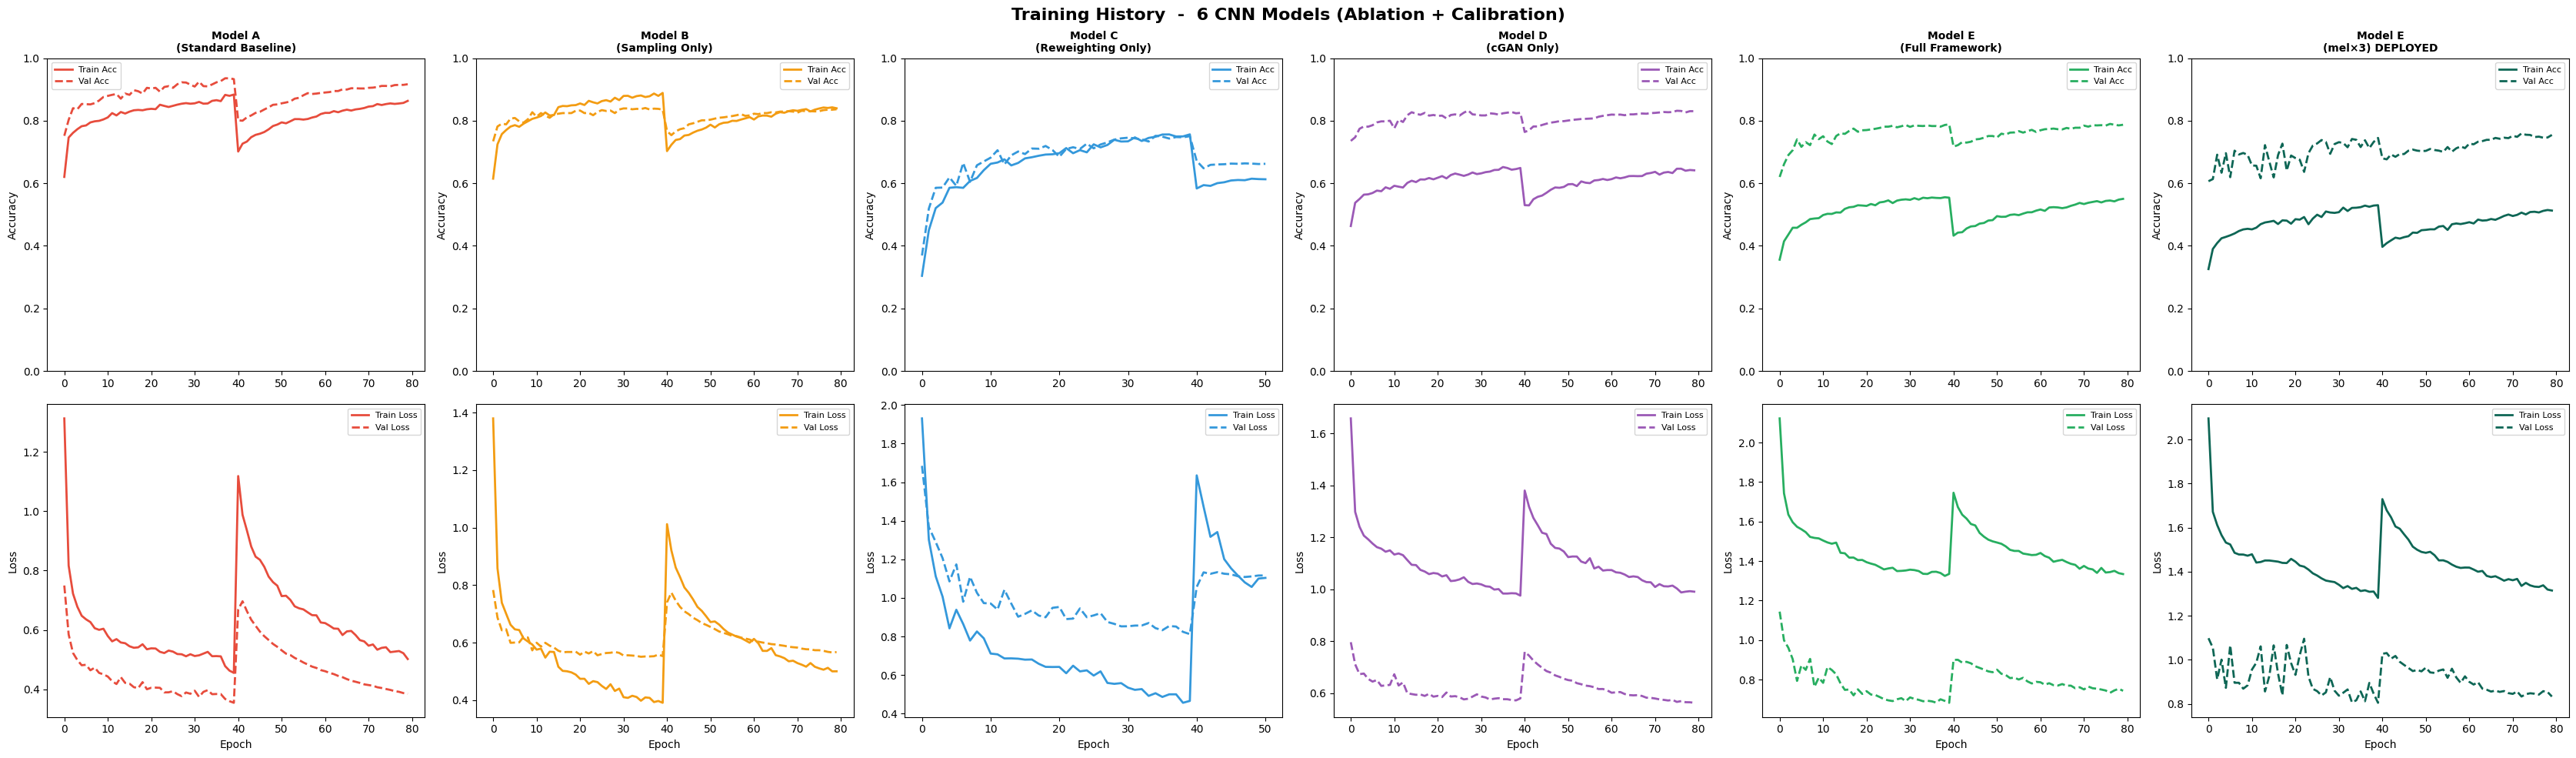

[OK] Training curves saved for 6 models.


In [ ]:
# Plot Training Curves (all trained models)

# Shared style dictionary
MODEL_STYLE = {
    "Model_A_Standard_Baseline": {"color": "#e74c3c", "display": "Model A\n(Standard Baseline)", "ls": "-"},
    "Model_B_Sampling_Only":     {"color": "#f39c12", "display": "Model B\n(Sampling Only)",     "ls": "--"},
    "Model_C_Reweighting_Only":  {"color": "#3498db", "display": "Model C\n(Reweighting Only)",  "ls": "-."},
    "Model_D_cGAN_Only":         {"color": "#9b59b6", "display": "Model D\n(cGAN Only)",         "ls": ":"},
    "Model_E_Full_Framework":    {"color": "#27ae60", "display": "Model E\n(Full Framework)",    "ls": "-"},
    "Model_E_melboost_3_0":      {"color": "#0e6655", "display": "Model E\n(mel×3) DEPLOYED",    "ls": "-"},
}

# Grid auto-sizes to however many models were actually trained
n_models = len(histories)
fig, axes = plt.subplots(2, n_models, figsize=(5.6 * n_models, 10), squeeze=False)
fig.suptitle(f"Training History  -  {n_models} CNN Models (Ablation + Calibration)",
             fontweight="bold", fontsize=16)

for col, (name, h) in enumerate(histories.items()):
    style = MODEL_STYLE.get(name, {"color": "#7f8c8d", "display": name.replace("_", " ")})
    color = style["color"]

    ax_acc  = axes[0, col]
    ax_loss = axes[1, col]

    ax_acc.plot(h["accuracy"],     label="Train Acc", color=color, linewidth=2)
    ax_acc.plot(h["val_accuracy"], label="Val Acc",   color=color, linewidth=2, linestyle="--")
    ax_acc.set_title(style["display"], fontweight="bold", fontsize=10)
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend(fontsize=8)
    ax_acc.set_ylim([0, 1])

    ax_loss.plot(h["loss"],     label="Train Loss", color=color, linewidth=2)
    ax_loss.plot(h["val_loss"], label="Val Loss",   color=color, linewidth=2, linestyle="--")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend(fontsize=8)
    ax_loss.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_curves_all_models.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"[OK] Training curves saved for {n_models} models.")

## SECTION 3: MODEL EVALUATION & FAIRNESS ANALYSIS

Generates predictions, computes fairness metrics (EOD, calibration) and produces the comparison tables and visualisations used to select and validate the deployed model.

# Prediction & Evaluation Helpers

In [ ]:
def get_predictions(model, df_split):

    paths  = df_split["image_path"].tolist()
    labels = df_split["label"].tolist()

    all_probs = []
    # Process in batches to avoid OOM
    for i in tqdm(range(0, len(paths), BATCH_SIZE), desc="Predicting"):
        batch_paths = paths[i:i+BATCH_SIZE]
        imgs = []
        for p in batch_paths:
            try:
                img = Image.open(p).convert("RGB").resize(IMG_SIZE)
                imgs.append(np.array(img, dtype=np.float32))   # NO /255.0
            except:
                imgs.append(np.zeros((*IMG_SIZE, 3), dtype=np.float32))
        batch_tensor = np.stack(imgs)
        probs = model.predict(batch_tensor, verbose=0)
        all_probs.extend(probs)

    all_probs  = np.array(all_probs)
    pred_labels = all_probs.argmax(axis=1)
    return np.array(labels), pred_labels, all_probs


def compute_standard_metrics(y_true, y_pred, y_probs):

    # Returns dict of standard diagnostic performance metrics.

    acc  = accuracy_score(y_true, y_pred)
    # Multi-class AUC (OvR macro)
    try:
        auc = roc_auc_score(y_true, y_probs, multi_class="ovr", average="macro")
    except:
        auc = float("nan")

    # Per-class sensitivity (recall) & specificity
    n_classes = y_probs.shape[1]
    sensitivities, specificities = [], []
    for c in range(n_classes):
        y_bin  = (y_true == c).astype(int)
        y_pred_bin = (y_pred == c).astype(int)
        tp = ((y_bin == 1) & (y_pred_bin == 1)).sum()
        fn = ((y_bin == 1) & (y_pred_bin == 0)).sum()
        tn = ((y_bin == 0) & (y_pred_bin == 0)).sum()
        fp = ((y_bin == 0) & (y_pred_bin == 1)).sum()
        sensitivities.append(tp / (tp + fn + 1e-8))
        specificities.append(tn / (tn + fp + 1e-8))

    return {
        "accuracy"   : round(acc, 4),
        "auc_macro"  : round(auc, 4),
        "sensitivity": round(np.mean(sensitivities), 4),  # macro avg
        "specificity": round(np.mean(specificities), 4),
        "per_class_sensitivity": {CLASS_NAMES[i]: round(s, 4)
                                   for i, s in enumerate(sensitivities)},
        "per_class_specificity": {CLASS_NAMES[i]: round(s, 4)
                                   for i, s in enumerate(specificities)},
    }


# Fairness Metrics

In [ ]:
# Fairness Metrics
def compute_fairness_metrics(df_split, y_true, y_pred, y_probs,
                              subgroup_col="age_group"):
    MEL_IDX = CLASS_NAMES.index("mel")


    df_split = df_split.reset_index(drop=True)

    groups = df_split[subgroup_col].unique()
    tpr_per_group = {}
    ppr_per_group = {}

    for grp in groups:
        mask = (df_split[subgroup_col] == grp).values

        y_true_g = y_true[mask]
        y_pred_g = y_pred[mask]

        mel_mask_g = (y_true_g == MEL_IDX)
        if mel_mask_g.sum() == 0:
            tpr_per_group[grp] = float("nan")
        else:
            tpr_per_group[grp] = round(
                ((y_pred_g == MEL_IDX) & mel_mask_g).sum() / mel_mask_g.sum(), 4
            )

        if len(y_pred_g) == 0:
            ppr_per_group[grp] = float("nan")
        else:
            ppr_per_group[grp] = round(
                (y_pred_g == MEL_IDX).sum() / len(y_pred_g), 4
            )

    valid_tpr = {k: v for k, v in tpr_per_group.items() if not np.isnan(v)}
    valid_ppr = {k: v for k, v in ppr_per_group.items() if not np.isnan(v)}

    eod = round(max(valid_tpr.values()) - min(valid_tpr.values()), 4) \
          if len(valid_tpr) >= 2 else float("nan")
    dp  = round(max(valid_ppr.values()) - min(valid_ppr.values()), 4) \
          if len(valid_ppr) >= 2 else float("nan")

    return {
        "subgroup_col": subgroup_col,
        "EOD"         : eod,
        "DP"          : dp,
        "TPR_per_group": tpr_per_group,
        "PPR_per_group": ppr_per_group,
    }

# Run Full Evaluation on All Trained Models

In [ ]:
# Run Full Evaluation on All Trained Models


def compute_ece(y_true, y_probs, n_bins=10):
    """Expected Calibration Error — how well confidence matches actual accuracy.
    ECE = 0 is perfect calibration."""
    confidences = y_probs.max(axis=1)
    predictions = y_probs.argmax(axis=1)
    accuracies  = (predictions == y_true)

    bin_edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n   = len(y_true)

    for i in range(n_bins):
        lo, hi = bin_edges[i], bin_edges[i + 1]
        mask   = (confidences >= lo) & (confidences < hi)
        if mask.sum() == 0:
            continue
        bin_acc  = accuracies[mask].mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / n) * abs(bin_acc - bin_conf)

    return round(float(ece), 4)


# Build models_dict: ablation + all calibration variants 

models_dict = {}

# Ablation study (Models A–E) — The core 5-model experiment
for tag, var_name in [
    ("Model_A_Standard_Baseline", "model_a"),
    ("Model_B_Sampling_Only",     "model_b"),
    ("Model_C_Reweighting_Only",  "model_c"),
    ("Model_D_cGAN_Only",         "model_d"),
    ("Model_E_Full_Framework",    "model_e"),
]:
    m = globals().get(var_name)
    if m is not None:
        models_dict[tag] = m

# Calibration sweep — Model E @ varying mel_boost (Cell 7b)
for boost in [3.0]:
    suffix = str(boost).replace(".", "_")
    m = globals().get(f"model_e_b{suffix}")
    if m is not None:
        models_dict[f"Model_E_melboost_{suffix}"] = m


# Main evaluation loop
MEL_IDX = CLASS_NAMES.index("mel")
all_results = {}

for model_name, model in models_dict.items():
    print(f"\n{'='*60}")
    print(f"  EVALUATING: {model_name}")
    print(f"{'='*60}")

    y_true, y_pred, y_probs = get_predictions(model, df_test)

    std_metrics = compute_standard_metrics(y_true, y_pred, y_probs)
    ece         = compute_ece(y_true, y_probs)

    fairness_results = {}
    for col in ["age_group", "sex", "loc_zone"]:
        if col in df_test.columns:
            fairness_results[col] = compute_fairness_metrics(
                df_test.reset_index(drop=True), y_true, y_pred, y_probs,
                subgroup_col=col
            )

    all_results[model_name] = {
        "standard_metrics": std_metrics,
        "ece"             : ece,
        "fairness"        : fairness_results,
        "y_true"          : y_true,
        "y_pred"          : y_pred,
        "y_probs"         : y_probs,
    }

    mel_sens = std_metrics["per_class_sensitivity"]["mel"]

    print(f"\n  Standard Metrics:")
    print(f"    Accuracy         : {std_metrics['accuracy']:.4f}")
    print(f"    AUC (macro)      : {std_metrics['auc_macro']:.4f}")
    print(f"    Sensitivity      : {std_metrics['sensitivity']:.4f}  (macro avg)")
    print(f"    MELANOMA Sens.   : {mel_sens:.4f}  <-- the clinical metric")
    print(f"    Specificity      : {std_metrics['specificity']:.4f}")
    print(f"    ECE              : {ece:.4f}")

    print(f"\n  Fairness Metrics:")
    for col, fm in fairness_results.items():
        eod_val = fm['EOD'] if not (isinstance(fm['EOD'], float) and np.isnan(fm['EOD'])) else float('nan')
        dp_val  = fm['DP']  if not (isinstance(fm['DP'],  float) and np.isnan(fm['DP']))  else float('nan')
        print(f"    [{col}] EOD={eod_val:.4f}  |  DP={dp_val:.4f}")

print(f"\n{'='*60}")
print(f"  All {len(models_dict)} models evaluated successfully.")
print(f"{'='*60}")



  EVALUATING: Model_A_Standard_Baseline


Predicting: 100%|██████████| 47/47 [00:21<00:00,  2.23it/s]



  Standard Metrics:
    Accuracy         : 0.8609
    AUC (macro)      : 0.9818
    Sensitivity      : 0.7665  (macro avg)
    MELANOMA Sens.   : 0.3916  <-- the clinical metric
    Specificity      : 0.9557
    ECE              : 0.0174

  Fairness Metrics:
    [age_group] EOD=0.2237  |  DP=0.0585
    [sex] EOD=0.1541  |  DP=0.0291
    [loc_zone] EOD=0.6800  |  DP=0.0438

  EVALUATING: Model_B_Sampling_Only


Predicting: 100%|██████████| 47/47 [00:21<00:00,  2.22it/s]



  Standard Metrics:
    Accuracy         : 0.7890
    AUC (macro)      : 0.9492
    Sensitivity      : 0.5790  (macro avg)
    MELANOMA Sens.   : 0.2651  <-- the clinical metric
    Specificity      : 0.9366
    ECE              : 0.0631

  Fairness Metrics:
    [age_group] EOD=0.0419  |  DP=0.0653
    [sex] EOD=0.0499  |  DP=0.0208
    [loc_zone] EOD=0.3438  |  DP=0.0838

  EVALUATING: Model_C_Reweighting_Only


...


  Standard Metrics:
    Accuracy         : 0.8053
    AUC (macro)      : 0.9536
    Sensitivity      : 0.6228  (macro avg)
    MELANOMA Sens.   : 0.2831  <-- the clinical metric
    Specificity      : 0.9383
    ECE              : 0.0608

  Fairness Metrics:
    [age_group] EOD=0.0621  |  DP=0.0728
    [sex] EOD=0.0285  |  DP=0.0159
    [loc_zone] EOD=0.3750  |  DP=0.0894

  EVALUATING: Model_E_Full_Framework


Predicting: 100%|██████████| 47/47 [00:19<00:00,  2.37it/s]



  Standard Metrics:
    Accuracy         : 0.7490
    AUC (macro)      : 0.9346
    Sensitivity      : 0.6301  (macro avg)
    MELANOMA Sens.   : 0.3012  <-- the clinical metric
    Specificity      : 0.9407
    ECE              : 0.0608

  Fairness Metrics:
    [age_group] EOD=0.0114  |  DP=0.0989
    [sex] EOD=0.0070  |  DP=0.0167
    [loc_zone] EOD=0.4062  |  DP=0.1006

  EVALUATING: Model_E_melboost_3_0


Predicting: 100%|██████████| 47/47 [00:19<00:00,  2.37it/s]


  Standard Metrics:
    Accuracy         : 0.7327
    AUC (macro)      : 0.9324
    Sensitivity      : 0.6369  (macro avg)
    MELANOMA Sens.   : 0.5301  <-- the clinical metric
    Specificity      : 0.9445
    ECE              : 0.0603

  Fairness Metrics:
    [age_group] EOD=0.1154  |  DP=0.1834
    [sex] EOD=0.0273  |  DP=0.0314
    [loc_zone] EOD=0.5938  |  DP=0.0876

  All 6 models evaluated successfully.


# Levelling-Down Diagnostic

In [ ]:
# Levelling-Down Diagnostic (Does a lower EOD reflect genuine uplift, or just uniform degradation?)
import numpy as np, pandas as pd

BASELINE_KEY = "Model_A_Standard_Baseline"

def levelling_down_report(all_results, models_dict, axis="age_group",
                          baseline_key=BASELINE_KEY):
    base_tpr = all_results[baseline_key]["fairness"][axis]["TPR_per_group"]
    groups   = [g for g, v in base_tpr.items() if not (v is None or np.isnan(v))]

    rows = []
    for mname in models_dict:
        fair  = all_results[mname]["fairness"][axis]
        tpr   = fair["TPR_per_group"]
        vals  = {g: tpr.get(g) for g in groups
                 if tpr.get(g) is not None and not np.isnan(tpr.get(g))}
        if not vals:
            continue

        worst_grp = min(vals, key=vals.get)
        worst_tpr = vals[worst_grp]
        best_tpr  = max(vals.values())

        # Compare every group against the baseline model
        deltas    = {g: vals[g] - base_tpr[g] for g in vals}
        n_worse   = sum(1 for d in deltas.values() if d < -0.01)
        n_better  = sum(1 for d in deltas.values() if d >  0.01)

        if mname == baseline_key:
            verdict = "— (baseline)"
        elif n_worse == len(deltas):
            verdict = "LEVELLING DOWN (all groups worse)"
        elif n_better > 0 and worst_tpr >= base_tpr[worst_grp]:
            verdict = "GENUINE UPLIFT"
        else:
            verdict = "MIXED"

        rows.append({
            "Model"            : MODEL_STYLE.get(mname, {}).get("display", mname).replace("\n", " "),
            "EOD"              : round(fair["EOD"], 4),
            "Worst group"      : worst_grp,
            "Worst-group TPR"  : round(worst_tpr, 4),
            "vs baseline worst": round(worst_tpr - base_tpr[worst_grp], 4),
            "Best-group TPR"   : round(best_tpr, 4),
            "Groups improved"  : f"{n_better}/{len(deltas)}",
            "Verdict"          : verdict,
        })

    return pd.DataFrame(rows).set_index("Model")

for axis in ["age_group", "sex", "loc_zone"]:
    print("\n" + "=" * 78)
    print(f"  LEVELLING-DOWN DIAGNOSTIC  —  melanoma TPR by {axis}")
    print("=" * 78)
    tbl = levelling_down_report(all_results, models_dict, axis=axis)
    print(tbl.to_string())
    tbl.to_csv(RESULTS_DIR / f"levelling_down_{axis}.csv")

print("\n[OK] Levelling-down diagnostics saved.")
print("""
READ THIS TABLE AS:
  GENUINE UPLIFT      -> worst group improved AND worst-group TPR >= baseline's.
                         This is the result the framework is SUPPOSED to produce.
  LEVELLING DOWN      -> every group got worse. EOD fell only because the model
                         became uniformly bad. NOT a clinical improvement.
  MIXED               -> some groups up, some down. Report honestly.
""")


  LEVELLING-DOWN DIAGNOSTIC  —  melanoma TPR by age_group
                                EOD Worst group  Worst-group TPR  vs baseline worst  Best-group TPR Groups improved                            Verdict
Model                                                                                                                                                 
Model A (Standard Baseline)  0.2237  MiddleAged           0.3148             0.0000          0.5385             0/3                       — (baseline)
Model B (Sampling Only)      0.0419  YoungAdult           0.2308            -0.3077          0.2727             0/3  LEVELLING DOWN (all groups worse)
Model C (Reweighting Only)   0.0670  MiddleAged           0.2407            -0.0741          0.3077             0/3  LEVELLING DOWN (all groups worse)
Model D (cGAN Only)          0.0621  YoungAdult           0.2308            -0.3077          0.2929             0/3  LEVELLING DOWN (all groups worse)
Model E (Full Framework)     0.0114

# Summary Comparison Table

In [154]:
print("\n" + "=" * 70)
print("  COMPREHENSIVE MODEL COMPARISON TABLE")
print("=" * 70)

comparison_rows = []
for mname, res in all_results.items():
    sm = res["standard_metrics"]
    row = {
        "Model"       : mname.replace("_", " "),
        "Accuracy"    : sm["accuracy"],
        "AUC (macro)" : sm["auc_macro"],
        "Sensitivity" : sm["sensitivity"],
        "Specificity" : sm["specificity"],
        "ECE"         : res["ece"],
    }
    for col in ["age_group", "sex", "loc_zone"]:
        if col in res["fairness"]:
            fm = res["fairness"][col]
            row[f"EOD ({col})"] = fm["EOD"]
            row[f"DP ({col})"]  = fm["DP"]
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
print(comparison_df)
comparison_df.to_csv(RESULTS_DIR / "model_comparison_table.csv")
print(f"\n[OK] Comparison table saved -> {RESULTS_DIR / 'model_comparison_table.csv'}")


  COMPREHENSIVE MODEL COMPARISON TABLE
                           Accuracy  AUC (macro)  Sensitivity  Specificity  \
Model                                                                        
Model A Standard Baseline    0.8609       0.9818       0.7665       0.9557   
Model B Sampling Only        0.7890       0.9492       0.5790       0.9366   
Model C Reweighting Only     0.6533       0.8899       0.5688       0.9280   
Model D cGAN Only            0.8053       0.9536       0.6228       0.9383   
Model E Full Framework       0.7490       0.9346       0.6301       0.9407   
Model E melboost 3 0         0.7327       0.9324       0.6369       0.9445   

                              ECE  EOD (age_group)  DP (age_group)  EOD (sex)  \
Model                                                                           
Model A Standard Baseline  0.0174           0.2237          0.0585     0.1541   
Model B Sampling Only      0.0631           0.0419          0.0653     0.0499   
Model C Rew

# Fairness Visualisation: EOD Across Models

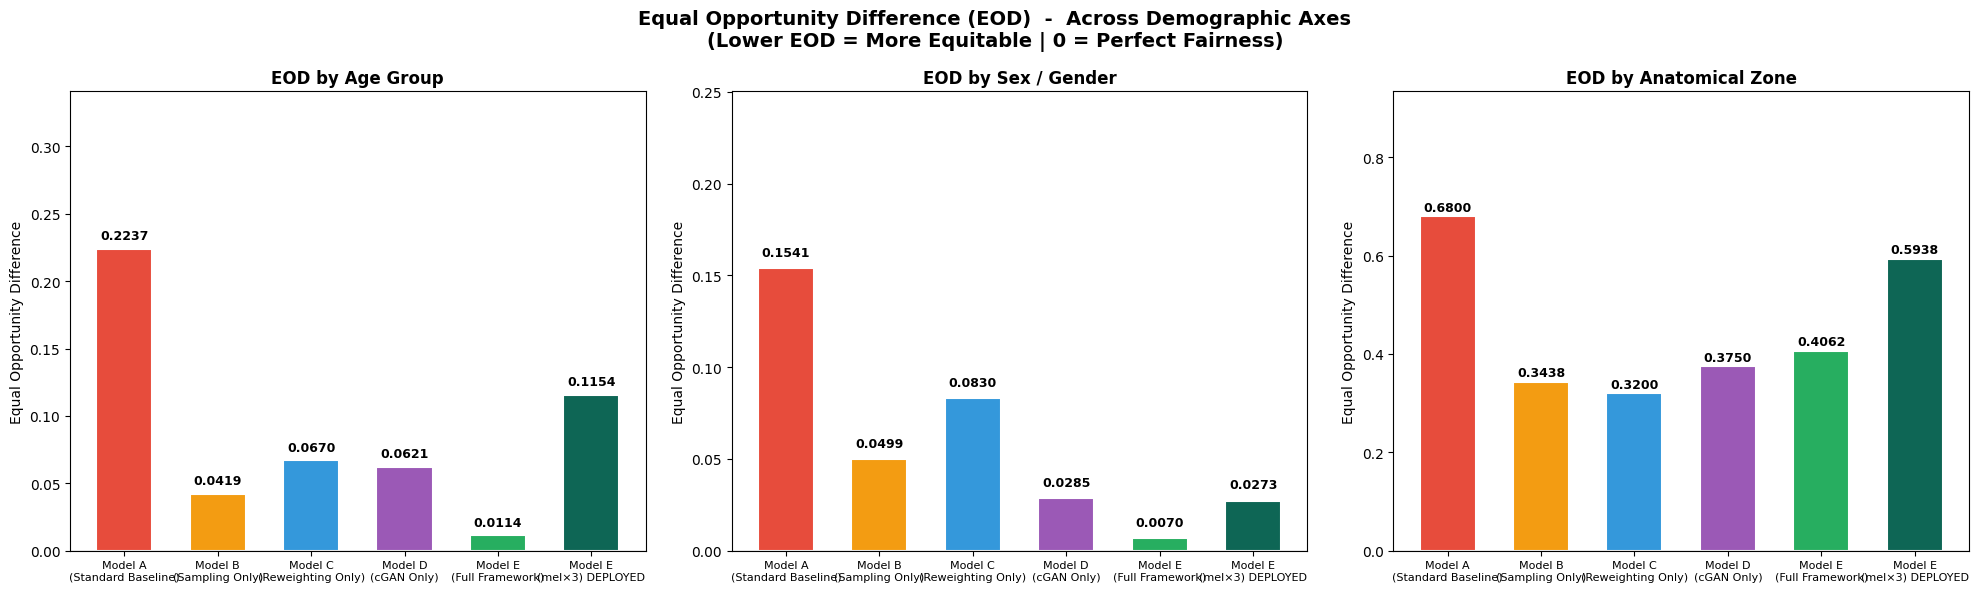

[OK] EOD comparison chart saved.


In [ ]:
# Fairness Visualisation: EOD Across Models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Equal Opportunity Difference (EOD)  -  Across Demographic Axes\n"
             "(Lower EOD = More Equitable | 0 = Perfect Fairness)",
             fontweight="bold", fontsize=14)

demo_cols   = ["age_group", "sex", "loc_zone"]
demo_labels = ["Age Group", "Sex / Gender", "Anatomical Zone"]

model_display_names = [MODEL_STYLE[m]["display"] for m in models_dict.keys()]
model_colors_list   = [MODEL_STYLE[m]["color"]   for m in models_dict.keys()]

for ax_i, (col, label) in enumerate(zip(demo_cols, demo_labels)):
    eod_values = []
    for mname in models_dict.keys():
        fm = all_results[mname]["fairness"].get(col, {})
        eod_values.append(fm.get("EOD", 0))

    bars = axes[ax_i].bar(model_display_names, eod_values, color=model_colors_list,
                           edgecolor="white", linewidth=1.5, width=0.6)
    axes[ax_i].set_title(f"EOD by {label}", fontweight="bold")
    axes[ax_i].set_ylabel("Equal Opportunity Difference")
    axes[ax_i].set_ylim([0, max(eod_values) * 1.3 + 0.05])
    axes[ax_i].axhline(0, color="black", linewidth=0.8)
    axes[ax_i].tick_params(axis="x", labelsize=8)

    for bar, val in zip(bars, eod_values):
        axes[ax_i].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.005,
                        f"{val:.4f}", ha="center", va="bottom",
                        fontweight="bold", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "fairness_eod_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("[OK] EOD comparison chart saved.")

# Subgroup Sensitivity Heatmap (Melanoma class)

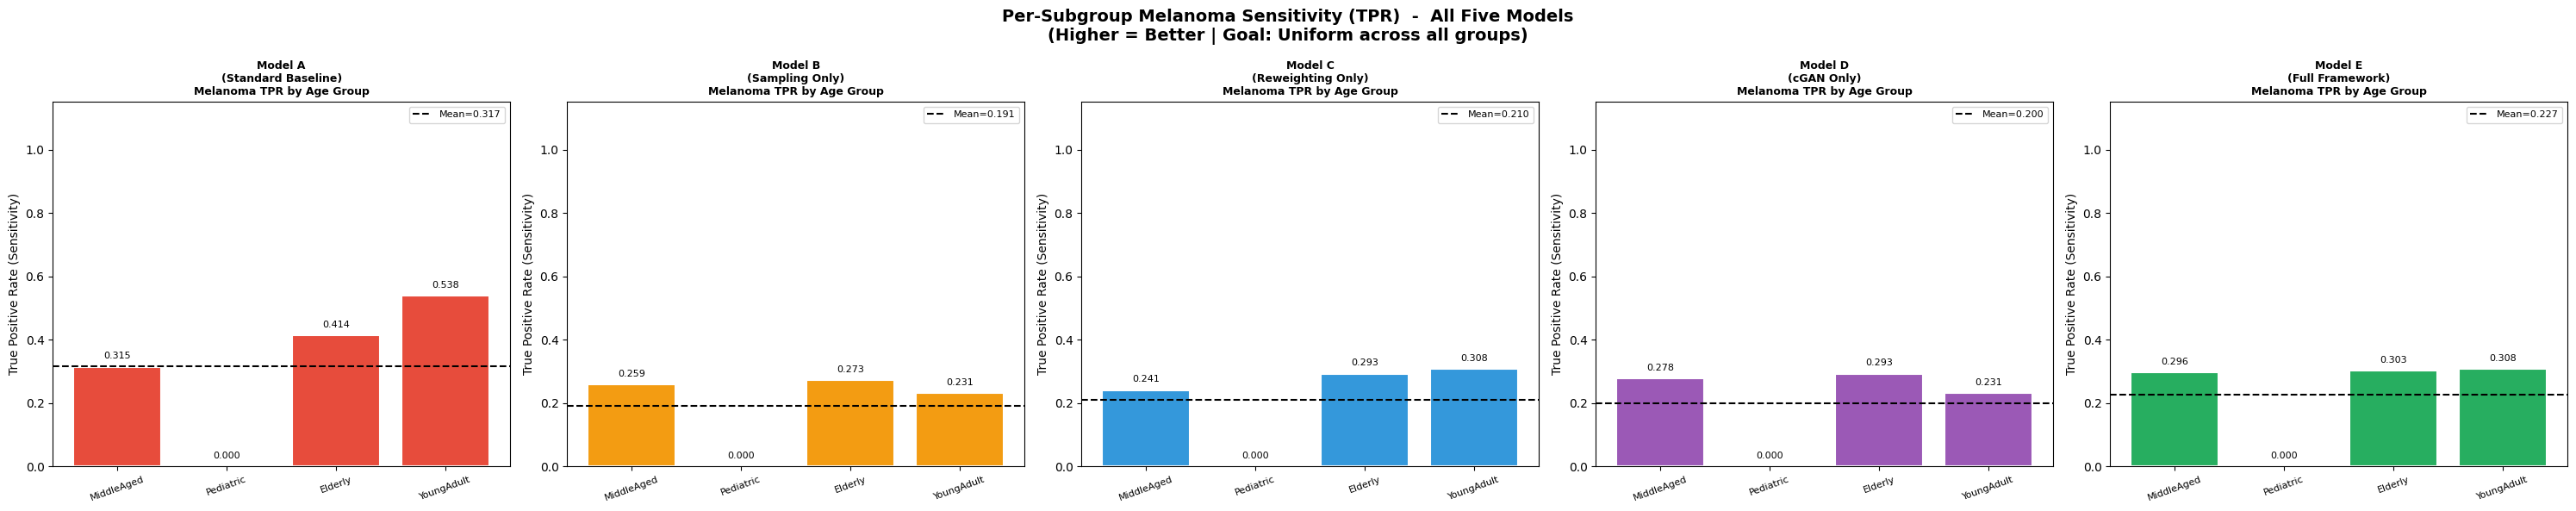

[OK] Subgroup sensitivity chart saved.


In [ ]:
# Subgroup Sensitivity Heatmap (Melanoma class)
fig, axes = plt.subplots(1, 6, figsize=(34, 7))
fig.suptitle("Per-Subgroup Melanoma Sensitivity (TPR)  -  All Six Models\n"
             "(Higher = Better | Goal: Uniform across all groups)",
             fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    style = MODEL_STYLE[mname]
    fm_age = all_results[mname]["fairness"].get("age_group", {})
    tpr_dict = fm_age.get("TPR_per_group", {})

    groups = list(tpr_dict.keys())
    tprs   = [tpr_dict[g] if not np.isnan(tpr_dict.get(g, float("nan"))) else 0
              for g in groups]

    bars = ax.bar(groups, tprs, color=style["color"], edgecolor="white", linewidth=1.5)
    ax.set_title(f"{style['display']}\nMelanoma TPR by Age Group", fontweight="bold", fontsize=9)
    ax.set_ylabel("True Positive Rate (Sensitivity)")
    ax.set_ylim([0, 1.15])
    ax.axhline(np.nanmean(tprs), color="black", linestyle="--",
               linewidth=1.5, label=f"Mean={np.nanmean(tprs):.3f}")
    ax.legend(fontsize=8)
    ax.set_xticklabels(groups, rotation=20, fontsize=8)

    for bar, val in zip(bars, tprs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "subgroup_melanoma_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("Subgroup sensitivity chart saved.")


# Confusion Matrix per Model

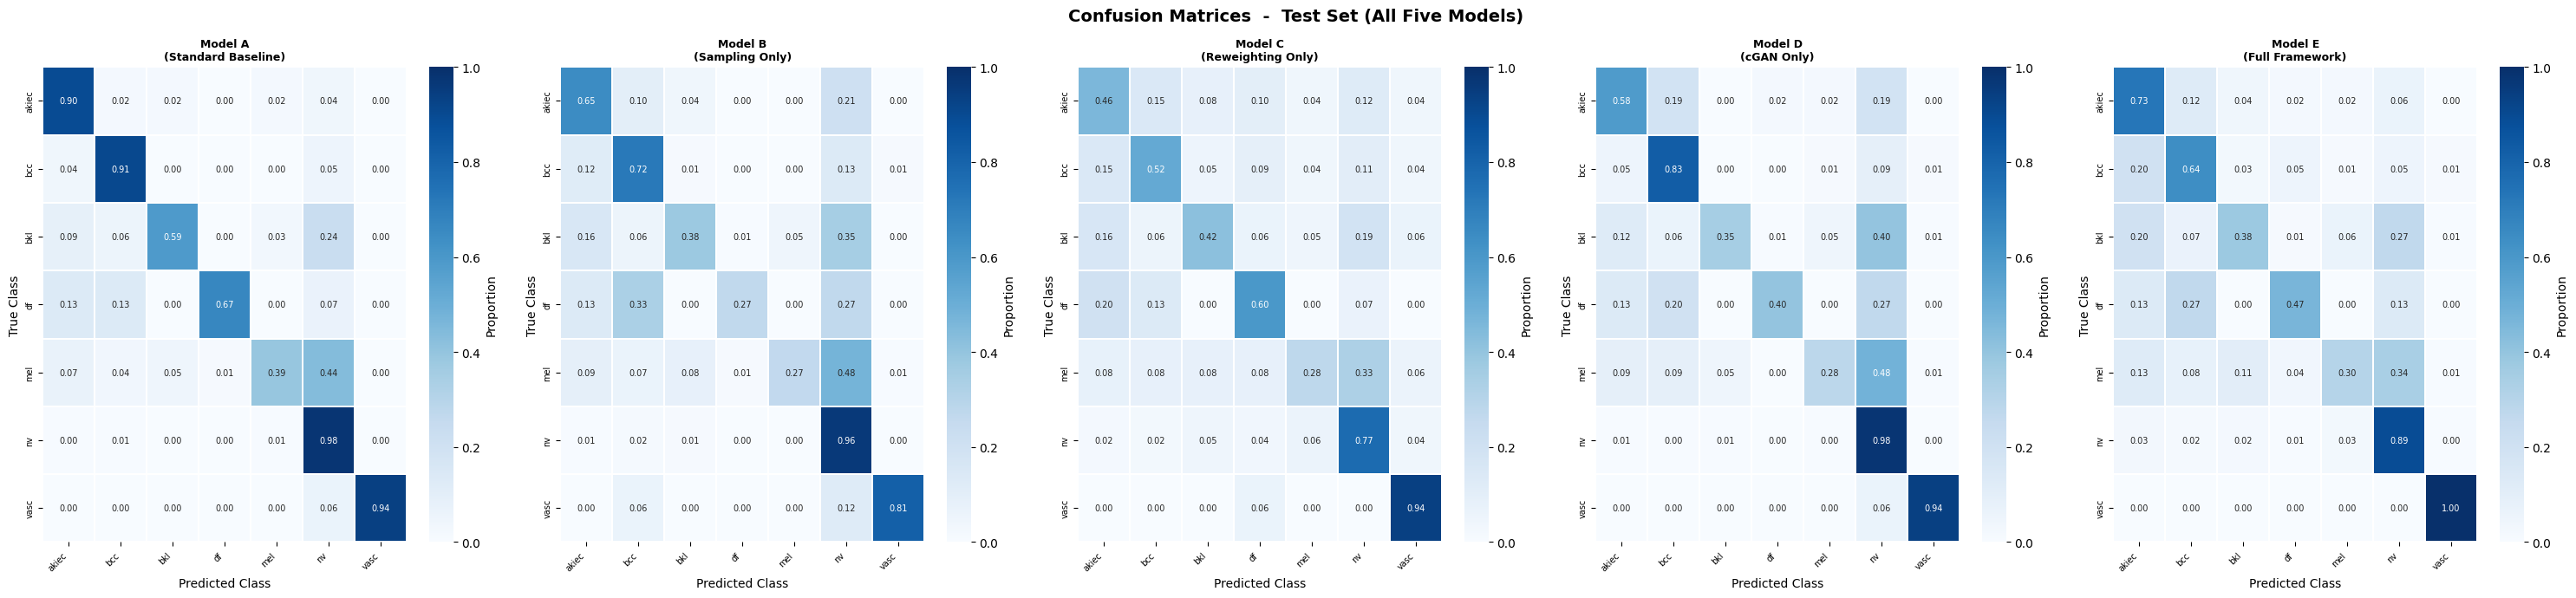

[OK] Confusion matrices saved.


In [ ]:
# Confusion Matrix for Each Model
fig, axes = plt.subplots(1, 6, figsize=(36, 7))
fig.suptitle("Confusion Matrices  -  Test Set (All Six Models)", fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    y_true = all_results[mname]["y_true"]
    y_pred = all_results[mname]["y_pred"]
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, linewidths=0.3, linecolor="white",
                cbar_kws={"label": "Proportion"}, annot_kws={"size": 7})
    ax.set_title(MODEL_STYLE[mname]["display"], fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted Class"); ax.set_ylabel("True Class")
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved.")


# ROC Curves for Melanoma Class

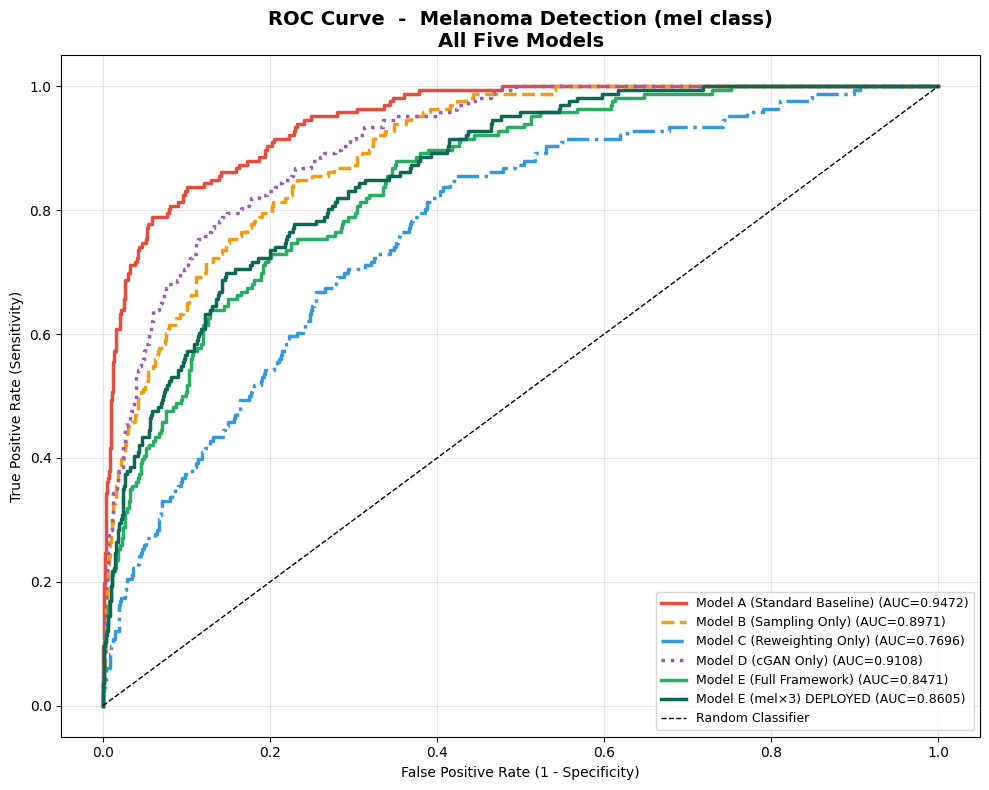

[OK] ROC curves saved.


In [ ]:
# ROC Curves for Melanoma Class
fig, ax = plt.subplots(figsize=(10, 8))
MEL_IDX = CLASS_NAMES.index("mel")

for mname in models_dict.keys():
    style   = MODEL_STYLE[mname]
    y_true  = all_results[mname]["y_true"]
    y_probs = all_results[mname]["y_probs"]

    y_bin   = (y_true == MEL_IDX).astype(int)
    y_score = y_probs[:, MEL_IDX]

    fpr, tpr, _ = roc_curve(y_bin, y_score)
    auc_val = roc_auc_score(y_bin, y_score)

    ax.plot(fpr, tpr, color=style["color"], linestyle=style["ls"], linewidth=2.5,
            label=f"{style['display'].replace(chr(10), ' ')} (AUC={auc_val:.4f})")

ax.plot([0,1],[0,1], "k--", linewidth=1, label="Random Classifier")
ax.set_title("ROC Curve  -  Melanoma Detection (mel class)\nAll Six Models",
             fontweight="bold", fontsize=14)
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves_melanoma.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROC curves saved.")

# Calibration Curves (ECE)

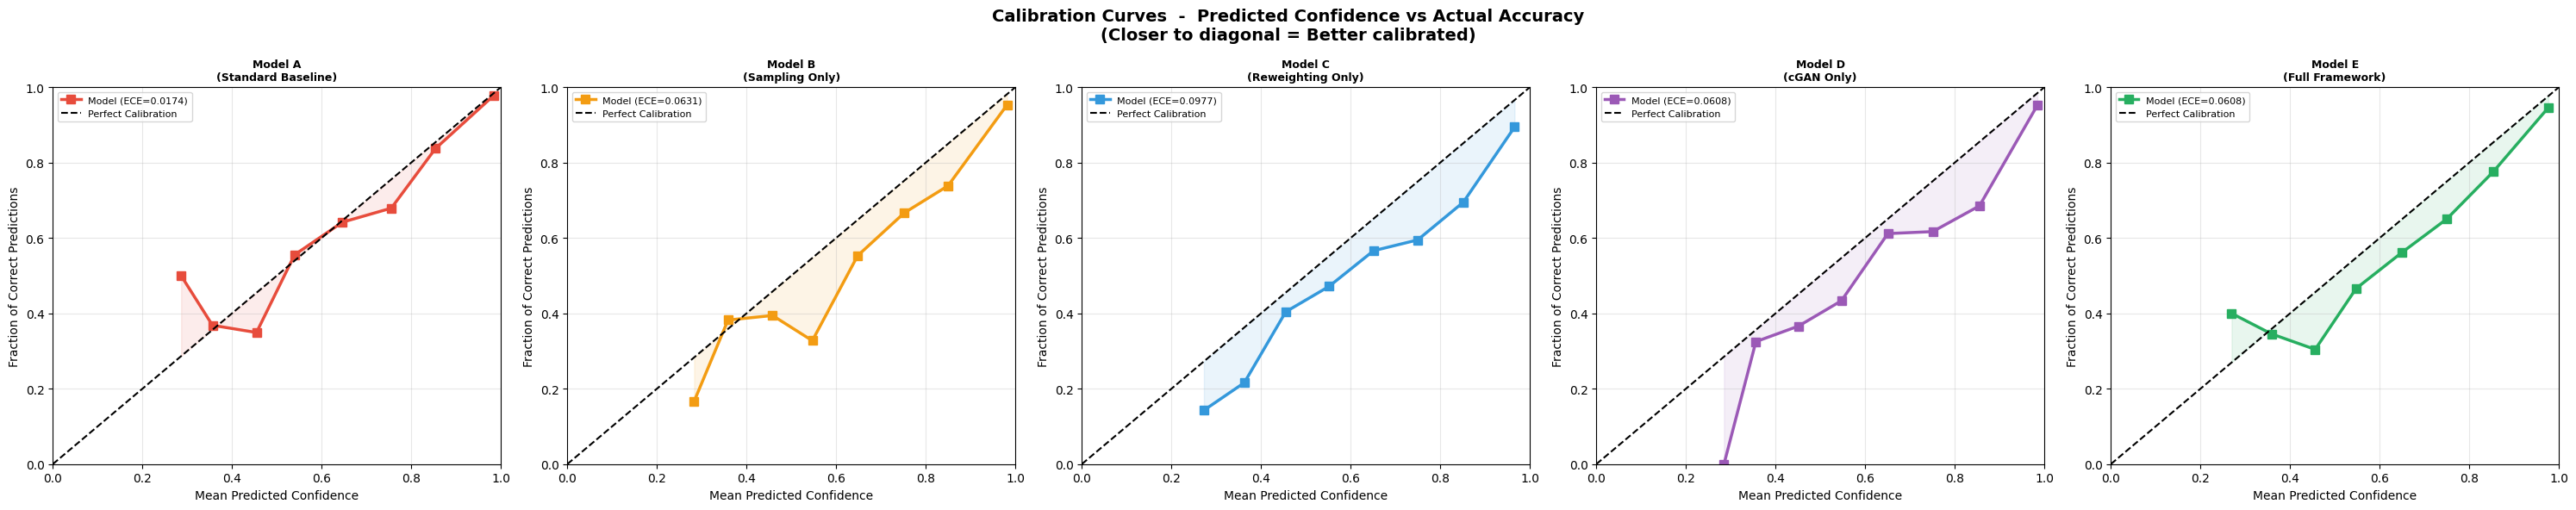

[OK] Calibration curves saved.


In [ ]:
# Calibration Curves (ECE)
fig, axes = plt.subplots(1, 6, figsize=(34, 7))
fig.suptitle("Calibration Curves  -  Predicted Confidence vs Actual Accuracy\n"
             "(Closer to diagonal = Better calibrated)",
             fontweight="bold", fontsize=14)

for ax_i, (mname, ax) in enumerate(zip(models_dict.keys(), axes)):
    style   = MODEL_STYLE[mname]
    y_true  = all_results[mname]["y_true"]
    y_probs = all_results[mname]["y_probs"]
    ece     = all_results[mname]["ece"]

    confidences = y_probs.max(axis=1)
    is_correct  = (y_probs.argmax(axis=1) == y_true).astype(int)

    fraction_pos, mean_pred = calibration_curve(is_correct, confidences, n_bins=10)

    ax.plot(mean_pred, fraction_pos, "s-", color=style["color"], linewidth=2.5,
            markersize=7, label=f"Model (ECE={ece:.4f})")
    ax.plot([0,1],[0,1], "k--", linewidth=1.5, label="Perfect Calibration")
    ax.fill_between(mean_pred, fraction_pos, mean_pred, alpha=0.1, color=style["color"])

    ax.set_title(style["display"], fontweight="bold", fontsize=9)
    ax.set_xlabel("Mean Predicted Confidence")
    ax.set_ylabel("Fraction of Correct Predictions")
    ax.legend(fontsize=8)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "calibration_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Calibration curves saved.")

# Full Fairness Trade-off Dashboard

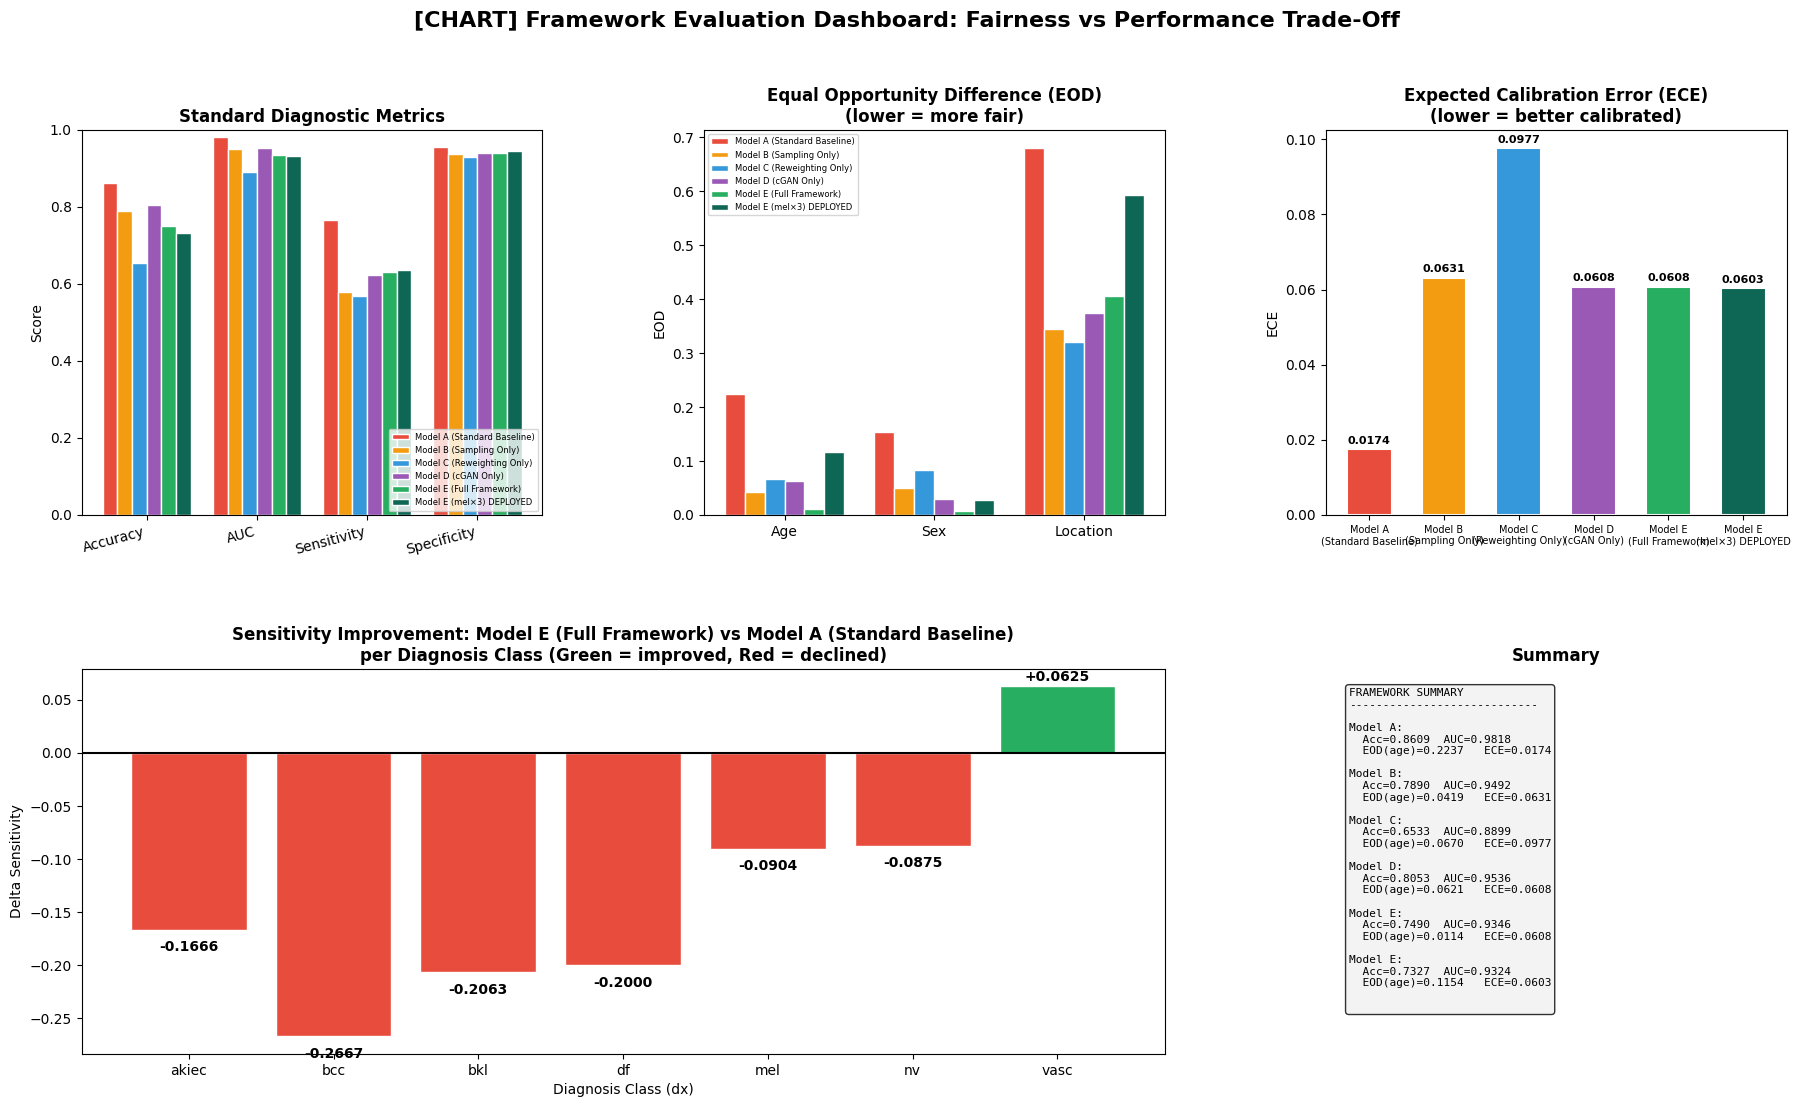

[OK] Full evaluation dashboard saved -> /kaggle/working/phase3_outputs/results/full_evaluation_dashboard.png


In [ ]:
# Full Fairness Trade-off Dashboard
fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
fig.suptitle("[CHART] Framework Evaluation Dashboard: Fairness vs Performance Trade-Off",
             fontweight="bold", fontsize=16)

model_display_names = [MODEL_STYLE[m]["display"] for m in models_dict.keys()]
model_colors_list   = [MODEL_STYLE[m]["color"]   for m in models_dict.keys()]
n_models = len(models_dict)

# Panel 1: Standard metrics comparison
ax1 = fig.add_subplot(gs[0, 0])
metrics_to_plot = ["accuracy", "auc_macro", "sensitivity", "specificity"]
metric_labels   = ["Accuracy", "AUC", "Sensitivity", "Specificity"]
x = np.arange(len(metrics_to_plot))
w = 0.8 / n_models  

for i, mname in enumerate(models_dict.keys()):
    style = MODEL_STYLE[mname]
    vals = [all_results[mname]["standard_metrics"][m] for m in metrics_to_plot]
    ax1.bar(x + i*w, vals, w, label=style["display"].replace("\n"," "),
            color=style["color"], edgecolor="white")

ax1.set_xticks(x + w * (n_models-1)/2)
ax1.set_xticklabels(metric_labels, rotation=15, ha="right")
ax1.set_ylim([0.0, 1.0])
ax1.set_title("Standard Diagnostic Metrics", fontweight="bold")
ax1.set_ylabel("Score")
ax1.legend(fontsize=6, loc="lower right")

# Panel 2: EOD across demographic axes
ax2 = fig.add_subplot(gs[0, 1])
eod_data = {}
for col in ["age_group", "sex", "loc_zone"]:
    eod_data[col] = []
    for mname in models_dict.keys():
        fm = all_results[mname]["fairness"].get(col, {})
        eod_data[col].append(fm.get("EOD", 0))

x2 = np.arange(3)
w2 = 0.8 / n_models
for i, mname in enumerate(models_dict.keys()):
    style = MODEL_STYLE[mname]
    eods = [eod_data[col][i] for col in ["age_group","sex","loc_zone"]]
    ax2.bar(x2 + i*w2, eods, w2, label=style["display"].replace("\n"," "),
            color=style["color"], edgecolor="white")
ax2.set_xticks(x2 + w2 * (n_models-1)/2)
ax2.set_xticklabels(["Age","Sex","Location"])
ax2.set_title("Equal Opportunity Difference (EOD)\n(lower = more fair)", fontweight="bold")
ax2.set_ylabel("EOD")
ax2.legend(fontsize=6)

# Panel 3: ECE comparison
ax3 = fig.add_subplot(gs[0, 2])
ece_vals = [all_results[m]["ece"] for m in models_dict.keys()]
bars3 = ax3.bar(model_display_names, ece_vals, color=model_colors_list,
                edgecolor="white", linewidth=1.5, width=0.6)
ax3.set_title("Expected Calibration Error (ECE)\n(lower = better calibrated)", fontweight="bold")
ax3.set_ylabel("ECE")
ax3.tick_params(axis="x", labelsize=7)
for bar, val in zip(bars3, ece_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f"{val:.4f}", ha="center", va="bottom", fontweight="bold", fontsize=8)

# Panel 4: Per-class sensitivity — Model A (Standard Baseline) vs Model E (Full Framework)
# Key Comparison of no-preprocessing vs full preprocessing framework
ax4 = fig.add_subplot(gs[1, :2])
per_class_a = all_results["Model_A_Standard_Baseline"]["standard_metrics"]["per_class_sensitivity"]
per_class_e = all_results["Model_E_Full_Framework"]["standard_metrics"]["per_class_sensitivity"]
delta = {cls: round(per_class_e[cls] - per_class_a[cls], 4) for cls in CLASS_NAMES}

bar_colors = ["#27ae60" if v >= 0 else "#e74c3c" for v in delta.values()]
bars4 = ax4.bar(delta.keys(), delta.values(), color=bar_colors, edgecolor="white")
ax4.axhline(0, color="black", linewidth=1.5)
ax4.set_title("Sensitivity Improvement: Model E (Full Framework) vs Model A (Standard Baseline)\n"
              "per Diagnosis Class (Green = improved, Red = declined)", fontweight="bold")
ax4.set_xlabel("Diagnosis Class (dx)")
ax4.set_ylabel("Delta Sensitivity")
for bar, val in zip(bars4, delta.values()):
    ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02
    ax4.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:+.4f}", ha="center", fontweight="bold", fontsize=10)

# Panel 5: Fairness Summary
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis("off")
summary_text = "FRAMEWORK SUMMARY\n" + "-"*28 + "\n\n"
for mname in models_dict.keys():
    sm  = all_results[mname]["standard_metrics"]
    eod_age = all_results[mname]["fairness"].get("age_group", {}).get("EOD","N/A")
    ece = all_results[mname]["ece"]
    short_name = MODEL_STYLE[mname]["display"].split("\n")[0]
    summary_text += f"{short_name}:\n"
    summary_text += f"  Acc={sm['accuracy']:.4f}  AUC={sm['auc_macro']:.4f}\n"
    summary_text += f"  EOD(age)={eod_age:.4f}   ECE={ece:.4f}\n\n"

ax5.text(0.05, 0.95, summary_text, transform=ax5.transAxes,
         fontsize=8, verticalalignment="top", fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#f0f0f0", alpha=0.8))
ax5.set_title("Summary", fontweight="bold")

plt.savefig(RESULTS_DIR / "full_evaluation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Full evaluation dashboard saved -> {RESULTS_DIR / 'full_evaluation_dashboard.png'}")

# Sensitivity vs Fairness Frontier

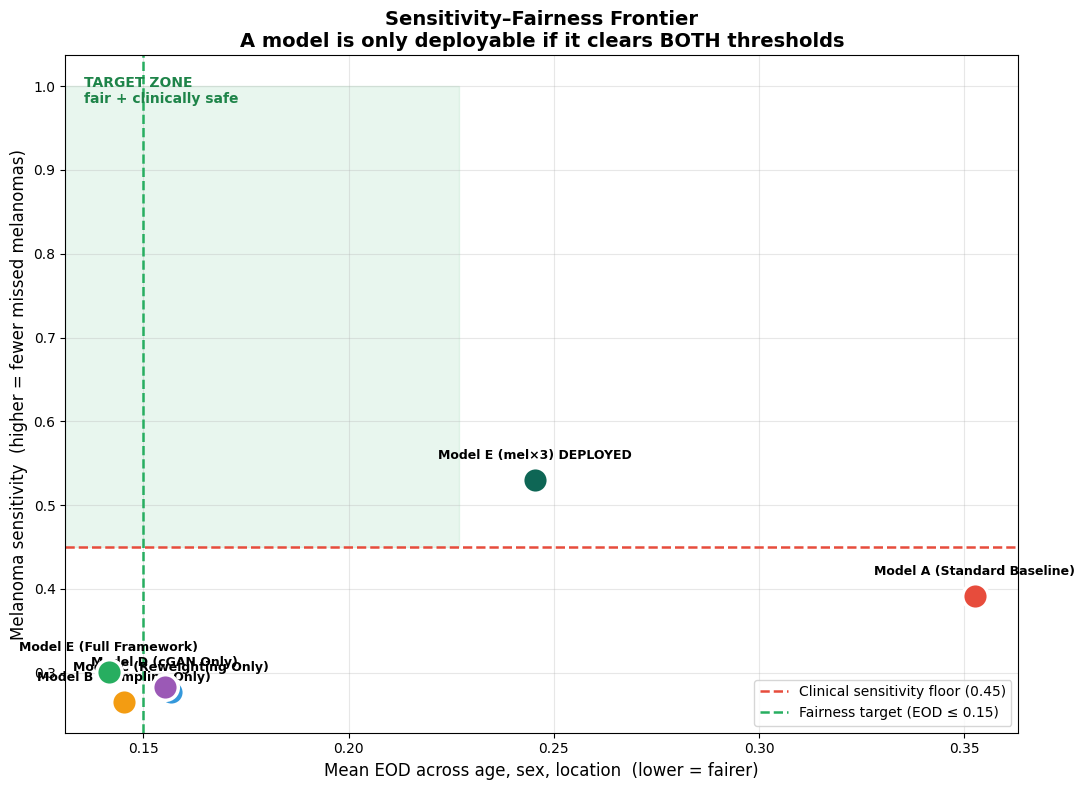

[OK] Frontier plot saved — this is your Chapter 5 headline figure.


In [ ]:
# Sensitivity vs Fairness Frontier
fig, ax = plt.subplots(figsize=(11, 8))

MIN_MEL_SENS = 0.45   # clinical floor

for mname in models_dict:
    st       = MODEL_STYLE[mname]
    sm       = all_results[mname]["standard_metrics"]
    mel_sens = sm["per_class_sensitivity"]["mel"]
    eods     = [all_results[mname]["fairness"][a]["EOD"]
                for a in ["age_group", "sex", "loc_zone"]]
    mean_eod = float(np.mean(eods))

    ax.scatter(mean_eod, mel_sens, s=340, color=st["color"],
               edgecolor="white", linewidth=2.5, zorder=3)
    ax.annotate(st["display"].replace("\n", " "),
                (mean_eod, mel_sens), textcoords="offset points",
                xytext=(0, 15), ha="center", fontsize=9, fontweight="bold")

ax.axhline(MIN_MEL_SENS, color="#e74c3c", ls="--", lw=1.8,
           label=f"Clinical sensitivity floor ({MIN_MEL_SENS})")
ax.axvline(0.15, color="#27ae60", ls="--", lw=1.8, label="Fairness target (EOD ≤ 0.15)")

#  Quadrant (fair and clinically safe)
ax.axhspan(MIN_MEL_SENS, 1.0, xmin=0, xmax=0.15/ax.get_xlim()[1],
           alpha=0.10, color="#27ae60")
ax.text(0.02, 0.97, "TARGET ZONE\nfair + clinically safe",
        transform=ax.transAxes, fontsize=10, fontweight="bold",
        color="#1e8449", va="top")

ax.set_xlabel("Mean EOD across age, sex, location  (lower = fairer)", fontsize=12)
ax.set_ylabel("Melanoma sensitivity  (higher = fewer missed melanomas)", fontsize=12)
ax.set_title("Sensitivity–Fairness Frontier\nA model is only deployable if it clears BOTH thresholds",
             fontweight="bold", fontsize=14)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "sensitivity_fairness_frontier.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Sensitivity–Fairness frontier plot saved -> {RESULTS_DIR / 'sensitivity_fairness_frontier.png'}")

# Save All Results

In [ ]:
# Save All Results
results_to_save = {}
for mname, res in all_results.items():
    results_to_save[mname] = {
        "standard_metrics": res["standard_metrics"],
        "ece"             : res["ece"],
        "fairness": {
            col: {
                "EOD"           : fm["EOD"],
                "DP"            : fm["DP"],
                "TPR_per_group" : fm["TPR_per_group"],
                "PPR_per_group" : fm["PPR_per_group"],
            }
            for col, fm in res["fairness"].items()
        }
    }

with open(RESULTS_DIR / "all_results.json", "w") as f:
    json.dump(results_to_save, f, indent=2)

print(f"\n[OK] All evaluation results saved -> {RESULTS_DIR / 'all_results.json'}")

# Model paths for HMS integration
# The HMS only needs TWO models which are the standard baseline (for the "before" comparison panel) and the full framework model (used for every live prediction)
DEPLOYED_KEY = "Model_E_melboost_3_0"

model_paths = {
    "baseline"     : str(MODELS_DIR / "Model_A_Standard_Baseline_final.h5"),
    "sampling_only": str(MODELS_DIR / "Model_B_Sampling_Only_final.h5"),
    "reweight_only": str(MODELS_DIR / "Model_C_Reweighting_Only_final.h5"),
    "cgan_only"    : str(MODELS_DIR / "Model_D_cGAN_Only_final.h5"),
    "enhanced_v2"  : str(MODELS_DIR / f"{DEPLOYED_KEY}_final.h5"),   # Deployed
}
with open(OUTPUT_DIR / "model_paths.json", "w") as f:
    json.dump(model_paths, f, indent=2)

print(f"[OK] Model paths saved -> {OUTPUT_DIR / 'model_paths.json'}")
print("\n[IMPORTANT] Update config.py in your HMS project:")
print('  MODEL_BASELINE    -> "Model_A_Standard_Baseline_final.h5"')
print('  MODEL_ENHANCED_V2 -> "Model_E_melboost_3_0_final.h5"')
print('[IMPORTANT] Update api.py:')
print('  ENHANCED_MODEL_KEY = "Model_E_melboost_3_0"')

print(f"Model paths saved -> {OUTPUT_DIR / 'model_paths.json'}")



[OK] All evaluation results saved -> /kaggle/working/phase3_outputs/results/all_results.json
[OK] Model paths saved -> /kaggle/working/phase3_outputs/model_paths.json

[IMPORTANT] Update config.py in your HMS project:
  MODEL_BASELINE    -> "Model_A_Standard_Baseline_final.h5"
  MODEL_ENHANCED_V2 -> "Model_E_melboost_3_0_final.h5"
[IMPORTANT] Update api.py:
  ENHANCED_MODEL_KEY = "Model_E_melboost_3_0"
[OK] Model paths saved -> /kaggle/working/phase3_outputs/model_paths.json


# Completion Summary

In [ ]:
# Phase 3 Completion Summary
print("\n" + "=" * 65)
print("  PHASE 1 COMPLETE  -  ALL STEPS FINISHED")
print("=" * 65)
print("""
STEP 1.1  -  Dataset Preparation:
  HAM10000 loaded, cleaned, engineered (age groups, loc zones)

STEP 1.2  -  Intersectional Stratified Sampling:
  70/15/15 stratified split across dx x age_group x sex x loc_zone

STEP 1.3  -  Adaptive Distribution-Aware Reweighting:
  Inverse-frequency sample weights computed for all training records

STEP 1.4  -  Conditional GAN (cGAN):
  WGAN-GP trained on HAM10000 (DCGAN-style architecture)
  Synthetic images generated for rare demographic subgroups
  FID + discriminator quality filtering applied

STEP 1.5  -  CNN Training (5-Model Ablation Study):
  Model A (Standard Baseline)  -  No preprocessing (similar to Ali et al. 2022)
  Model B (Sampling Only)      -  Intersectional stratified sampling only
  Model C (Reweighting Only)   -  Adaptive distribution-aware reweighting only
  Model D (cGAN Only)          -  Quality-controlled cGAN augmentation only
  Model E (Full Framework)     -  All three components combined
  Model E (Mel Boost 3.0)      -  Model E with mel_boost=3.0 (final deployed model)

STEP 1.6  -  Fairness Evaluation:
  Accuracy, AUC-ROC, Sensitivity, Specificity (all 5 models)
  EOD & Demographic Parity (age, sex, localization)
  Expected Calibration Error (ECE)
  Dashboard charts & comparison table saved

OUTPUTS SAVED TO:   ./phase1_outputs/
  models/     -> .h5 model files for all 5 models
  results/    -> charts, comparison table, all_results.json
  splits/     -> train/val/test CSVs
  cgan/       -> generator checkpoint, training curves
  synthetic_images/ -> generated images per rare subgroup

NEXT STEP -> Begin PHASE 2: HMS Backend (Flask + Database)
""")



  [DONE] PHASE 1 COMPLETE  -  ALL STEPS FINISHED

STEP 1.1  -  Dataset Preparation:
  [OK] HAM10000 loaded, cleaned, engineered (age groups, loc zones)

STEP 1.2  -  Intersectional Stratified Sampling:
  [OK] 70/15/15 stratified split across dx x age_group x sex x loc_zone

STEP 1.3  -  Adaptive Distribution-Aware Reweighting:
  [OK] Inverse-frequency sample weights computed for all training records

STEP 1.4  -  Conditional GAN (cGAN):
  [OK] WGAN-GP trained on HAM10000 (DCGAN-style architecture)
  [OK] Synthetic images generated for rare demographic subgroups
  [OK] FID + discriminator quality filtering applied

STEP 1.5  -  CNN Training (5-Model Ablation Study):
  [OK] Model A (Standard Baseline)  -  No preprocessing (Ali et al. 2022 replication)
  [OK] Model B (Sampling Only)      -  Intersectional stratified sampling only
  [OK] Model C (Reweighting Only)   -  Adaptive distribution-aware reweighting only
  [OK] Model D (cGAN Only)          -  Quality-controlled cGAN augmentation 

# Create ZIP file

In [ ]:
# Package trained models
import shutil, os

print("Model files saved:")
for f in sorted(MODELS_DIR.iterdir()):
    if f.suffix == ".h5":
        size_mb = f.stat().st_size / (1024 * 1024)
        print(f"  {f.name}  ({size_mb:.1f} MB)")

shutil.make_archive("/kaggle/working/melanoscan_trained_models", "zip", MODELS_DIR)
zip_size = os.path.getsize("/kaggle/working/melanoscan_trained_models.zip") / (1024*1024)
print(f"\n[OK] melanoscan_trained_models.zip ({zip_size:.1f} MB)")
print("Download from the Output panel → melanoscan_trained_models.zip")

Model files saved:
  Model_A_Standard_Baseline_final.h5  (31.4 MB)
  Model_A_Standard_Baseline_phase1_best.h5  (20.0 MB)
  Model_A_Standard_Baseline_phase2_best.h5  (31.4 MB)
  Model_B_Sampling_Only_final.h5  (31.4 MB)
  Model_B_Sampling_Only_phase1_best.h5  (20.0 MB)
  Model_B_Sampling_Only_phase2_best.h5  (31.4 MB)
  Model_C_Reweighting_Only_final.h5  (31.4 MB)
  Model_C_Reweighting_Only_phase1_best.h5  (20.0 MB)
  Model_C_Reweighting_Only_phase2_best.h5  (31.4 MB)
  Model_D_cGAN_Only_final.h5  (31.4 MB)
  Model_D_cGAN_Only_phase1_best.h5  (20.0 MB)
  Model_D_cGAN_Only_phase2_best.h5  (31.4 MB)
  Model_E_Full_Framework_final.h5  (31.4 MB)
  Model_E_Full_Framework_phase1_best.h5  (20.0 MB)
  Model_E_Full_Framework_phase2_best.h5  (31.4 MB)
  Model_E_melboost_3_0_final.h5  (31.4 MB)
  Model_E_melboost_3_0_phase1_best.h5  (20.0 MB)
  Model_E_melboost_3_0_phase2_best.h5  (31.4 MB)

[OK] melanoscan_trained_models.zip (447.1 MB)
Download from the Output panel → melanoscan_trained_models.zi

# Deployment Decision Summary

In [ ]:
# Melanoma-specific sensitivity
DEPLOYED_KEY = "Model_E_melboost_3_0"

print(f"{'Model':<32}{'Mel Sens':<12}{'Accuracy':<12}{'Mean EOD':<12}{'EOD (age+sex)'}")
print("-" * 82)
for m in models_dict:
    sm   = all_results[m]["standard_metrics"]
    mel  = sm["per_class_sensitivity"]["mel"]
    eods = [all_results[m]["fairness"][a]["EOD"] for a in ["age_group","sex","loc_zone"]]
    eod_as = np.mean(eods[:2])    # excludes the degenerate loc_zone 'Unknown' group
    name = MODEL_STYLE[m]["display"].replace("\n"," ")
    flag = "  <-- DEPLOYED" if m == DEPLOYED_KEY else ""
    print(f"{name:<32}{mel:<12.4f}{sm['accuracy']:<12.4f}{np.mean(eods):<12.4f}{eod_as:.4f}{flag}")

Model                           Mel Sens    Accuracy    Mean EOD    EOD (age+sex)
----------------------------------------------------------------------------------
Model A (Standard Baseline)     0.3916      0.8609      0.3526      0.1889
Model B (Sampling Only)         0.2651      0.7890      0.1452      0.0459
Model C (Reweighting Only)      0.2771      0.6533      0.1567      0.0750
Model D (cGAN Only)             0.2831      0.8053      0.1552      0.0453
Model E (Full Framework)        0.3012      0.7490      0.1415      0.0092
Model E (mel×3) DEPLOYED        0.5301      0.7327      0.2455      0.0713  <-- DEPLOYED
